# Multiple Game Analysis

## Loading all the libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from adjustText import *
import pandas as pd
from plotnine import *
import scipy.stats as st
from scipy.interpolate import interp1d
from matplotlib.ticker import MaxNLocator
%matplotlib inline

# Game Set for Analysis

Each game to evaluate should be on a different line in "games".

In [163]:
fileprefix = "../CardStock/output/Valet/"
games = [
    {"game":"Agram","name":"Agram", "player":3},
    #{"game":"Blackjack","name":"Blackjack", "player":1},
    {"game":"CrazyEights","name":"Crazy Eights", "player":3},
    {"game":"Cribbage","name":"Cribbage", "player":2},
    #{"game":"Cuckoo","name":"Cuckoo", "player":6},
    #{"game":"Euchre","name":"Euchre", "player":4},
    #{"game":"GoFish","name":"Go Fish", "player":4},
    #{"game":"GolfSix","name":"Golf-6", "player":4},
    #{"game":"GOPS","name":"Goofspiel", "player":2},
    #{"game":"Hearts","name":"Hearts", "player": 4},
    {"game":"Klaverjassen","name":"Klaverjassen", "player":4},
    #{"game":"LeducPoker","name":"Leudec Hold'em", "player":2},
    #{"game":"Pitch","name":"Pitch", "player":4},
    #{"game":"President","name":"President", "player":5},
    #{"game":"BlockRummy","name":"Rummy", "player":2},
    #{"game":"Scarto","name":"Scarto", "player":3},
    #{"game":"Schwimmen","name":"Schwimmen", "player":5},
    {"game":"Scopa","name":"Scopa", "player":2},
    #{"game":"Skittgube","name":"Skitgubbe", "player":3},
    #{"game":"Sueca","name":"Sueca", "player":4},
    #{"game":"Whist","name":"Whist", "player":4},    
]
gameframe = pd.DataFrame.from_dict(games)
gameframe["fileprefix"] = fileprefix
gameframe

,game,name,player,fileprefix
0,Agram,Agram,3,../CardStock/output/Valet/
1,CrazyEights,Crazy Eights,3,../CardStock/output/Valet/
2,Cribbage,Cribbage,2,../CardStock/output/Valet/
3,Klaverjassen,Klaverjassen,4,../CardStock/output/Valet/
4,Scopa,Scopa,2,../CardStock/output/Valet/


In [2]:
fileprefix = "../CardStock/output/CardStockVM/"
games = [
    {"game":"Agram","name":"Agram", "player":3},
    {"game":"Blackjack","name":"Blackjack", "player":1},
    {"game":"CrazyEights","name":"Crazy Eights", "player":3},
    {"game":"Cribbage","name":"Cribbage", "player":2},
    {"game":"Cuckoo","name":"Cuckoo", "player":6},
    {"game":"Euchre","name":"Euchre", "player":4},
    {"game":"GoFish","name":"Go Fish", "player":4},
    {"game":"GolfSix","name":"Golf-6", "player":4},
    {"game":"GOPS","name":"Goofspiel", "player":2},
    {"game":"Hearts","name":"Hearts", "player": 4},
    {"game":"Klaverjassen","name":"Klaverjassen", "player":4},
    {"game":"LeducPoker","name":"Leudec Hold'em", "player":2},
    {"game":"Pitch","name":"Pitch", "player":4},
    {"game":"President","name":"President", "player":5},
    {"game":"BlockRummy","name":"Rummy", "player":2},
    {"game":"Scarto","name":"Scarto", "player":3},
    {"game":"Schwimmen","name":"Schwimmen", "player":5},
    {"game":"Scopa","name":"Scopa", "player":2},
    {"game":"Skittgube","name":"Skitgubbe", "player":3},
    {"game":"Sueca","name":"Sueca", "player":4},
    {"game":"Whist","name":"Whist", "player":4},    
]
gameframe = pd.DataFrame.from_dict(games)
gameframe["fileprefix"] = fileprefix
gameframe

,game,name,player,fileprefix
0,Agram,Agram,3,../CardStock/output/CardStockVM/
1,Blackjack,Blackjack,1,../CardStock/output/CardStockVM/
2,CrazyEights,Crazy Eights,3,../CardStock/output/CardStockVM/
3,Cribbage,Cribbage,2,../CardStock/output/CardStockVM/
4,Cuckoo,Cuckoo,6,../CardStock/output/CardStockVM/
5,Euchre,Euchre,4,../CardStock/output/CardStockVM/
6,GoFish,Go Fish,4,../CardStock/output/CardStockVM/
7,GolfSix,Golf-6,4,../CardStock/output/CardStockVM/
8,GOPS,Goofspiel,2,../CardStock/output/CardStockVM/
9,Hearts,Hearts,4,../CardStock/output/CardStockVM/


In [2]:
fileprefix = "../CardStock/output/"
games = [

    {"game":"ShastaSam","name":"Shasta Sam", "player":2},
    {"game":"CaliforniaJack","name":"California Jack", "player":2},
    {"game":"Caterpillar","name":"Caterpillar", "player":2},
    {"game":"Coloretto","name":"Coloretto", "player":4},
    {"game":"Comet","name":"Comet", "player":2},
#    {"game":"Coup","name":"Coup", "player":4},
    {"game":"Escoba","name":"Escoba", "player":2},
    {"game":"LostCities","name":"Lost Cities", "player":2},
    {"game":"LAMA","name":"LAMA", "player":4},
    {"game":"NoThanks","name":"No Thanks", "player":4},
    {"game":"PageOne","name":"Page One", "player":3},
    {"game":"Knaves","name":"Knaves", "player":3},
    {"game":"NinetyEight","name":"Ninety Eight", "player":4},
    {"game":"SaneEights","name":"Sane Eights", "player":4},
    {"game":"SheepsheadPicker","name":"Sheepshead", "player":5},
    {"game":"Simon'sCat","name":"Simon's Cat", "player":4},
    {"game":"SpiteMalice","name":"Spite and Malice", "player":2},
    {"game":"TurnTheTide","name":"Turn The Tide", "player":3},
    {"game":"BottleImp","name":"The Bottle Imp", "player":3},
    {"game":"Pairs","name":"Pairs", "player":3},
    {"game":"PairsPort","name":"Pairs Port", "player":4},
    {"game":"Clocktowers","name":"Clocktowers", "player":2},
    {"game":"Briscola","name":"Briscola", "player":2},
    {"game":"Trifle","name":"Trifle", "player":2},
    {"game":"SixNimmt","name":"6 Nimmt", "player":5},
    {"game":"FoxInTheForest","name":"The Fox in the Forest", "player":2},
    {"game":"GermanWhist","name":"German Whist", "player":2},
    {"game":"Slobberhannes","name":"Slobberhannes", "player":4},
    {"game":"Polignac","name":"Polignac", "player":4},
    {"game":"StealingBundles","name":"Stealing Bundles", "player":2},
    {"game":"DuckSoup","name":"Duck Soup", "player":2},
    {"game":"Pico","name":"Pico", "player":2},
    {"game":"PicoTwo","name":"Pico 2", "player":2},
#    {"game":"Trio","name":"Trio", "player":4},
    {"game":"Diamant","name":"Diamant", "player":8},
    {"game":"LoveLetter","name":"Love Letter", "player":4},
    {"game":"Poison","name":"Poison", "player":5},
#    {"game":"Escalation","name":"Escalation!", "player":4},
#    {"game":"GoldRush","name":"Gold Rush!", "player":3},
    {"game":"AbandonAllArtichokes","name":"Abandon All Artichokes", "player":2},
    {"game":"Nanuk","name":"Nanuk", "player":6},
    {"game":"SushiGo","name":"Sushi Go!", "player":4},

]
gameframe = pd.DataFrame.from_dict(games)
gameframe["fileprefix"] = fileprefix
#gameframe = pd.concat([gameframe, gameframe2])
gameframe

,game,name,player,fileprefix
0,ShastaSam,Shasta Sam,2,../CardStock/output/
1,CaliforniaJack,California Jack,2,../CardStock/output/
2,Caterpillar,Caterpillar,2,../CardStock/output/
3,Coloretto,Coloretto,4,../CardStock/output/
4,Comet,Comet,2,../CardStock/output/
5,Escoba,Escoba,2,../CardStock/output/
6,LostCities,Lost Cities,2,../CardStock/output/
7,LAMA,LAMA,4,../CardStock/output/
8,NoThanks,No Thanks,4,../CardStock/output/
9,PageOne,Page One,3,../CardStock/output/


# Branching Factor

This first gather data into a dataframe, which will enable us to draw graphs to show how the branching factor of the game changes over time.

This data is from games with all **random** players.

In [164]:
first = True
for index, row in gameframe.iterrows():
    gf = pd.read_csv(row["fileprefix"] + row["game"] + "/" + str(row["player"]) + "/" + "R" * row["player"] + "/choice.csv")
    print(row["game"])
    gf["game"] = row["game"]
    gf["name"] = row["name"]
    if first:
        choiceframe = gf
        first = False
    else:
        choiceframe = pd.concat([choiceframe, gf])
    gf = pd.read_csv(row["fileprefix"] + row["game"] + "/" + str(row["player"]) + "/" + "M" + "R" * (row["player"] - 1) + "/choice.csv")
    gf["game"] = row["game"]
    gf["name"] = row["name"]
    choiceframe = pd.concat([choiceframe, gf])
#    gf = pd.read_csv(row["fileprefix"] + row["game"] + "/" + str(row["player"]) + "/" + "P" + "R" * (row["player"] - 1) + "/choice.csv")
#    gf["game"] = row["game"]
#    gf["name"] = row["name"]
#    choiceframe = pd.concat([choiceframe, gf])

Agram
CrazyEights
Cribbage
Klaverjassen
Scopa


In [87]:
choiceframe

,game,numPlayers,ai,imperfect,samples,tests,run,move,player,choices,choice,time,name
0,Agram,3,RRR,PRIVATE,10,1000,1,1,1,6,2,0,Agram
1,Agram,3,RRR,PRIVATE,10,1000,1,2,2,3,1,0,Agram
2,Agram,3,RRR,PRIVATE,10,1000,1,3,3,1,1,0,Agram
3,Agram,3,RRR,PRIVATE,10,1000,1,4,3,5,3,0,Agram
4,Agram,3,RRR,PRIVATE,10,1000,1,5,1,2,1,0,Agram
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3595,Scopa,2,MR,PRIVATE,10,1000,100,32,2,3,1,0,Scopa
3596,Scopa,2,MR,PRIVATE,10,1000,100,33,1,2,1,304,Scopa
3597,Scopa,2,MR,PRIVATE,10,1000,100,34,2,2,1,0,Scopa
3598,Scopa,2,MR,PRIVATE,10,1000,100,35,1,2,2,78,Scopa


## Convergence

The **Convergence** is a summary, the average slope of all the runs for a game, squished into a number between 0 and 1. 0.5 means a flat horizontal line, 0 is straight up, and 1 is straight down.

In [88]:
cseq = []
cf = choiceframe[choiceframe["ai"].str.startswith("R")]
for index, row in gameframe.iterrows():
    print(row["game"])
    cf2 = cf[(cf["game"]==row["game"])]
    convergence = 0
    count = 0
    for i in range(100):
        tempf = cf2[(cf2["run"]==i)]
        if len(tempf) > 1:
            slope, intercept, r_value, p_value, std_error = st.linregress(tempf["move"], tempf["choices"])
            convergence += (1 - (slope / 2 + 0.5))
            count += 1
    cseq.append(convergence / count)

Agram
CrazyEights
Cribbage
Klaverjassen
Scopa


In [89]:
gameframe["convergence"] = cseq
gameframe

,game,name,player,fileprefix,convergence
0,Agram,Agram,3,../CardStock/output/Valet/,0.594787
1,CrazyEights,Crazy Eights,3,../CardStock/output/Valet/,0.529805
2,Cribbage,Cribbage,2,../CardStock/output/Valet/,0.717848
3,Klaverjassen,Klaverjassen,4,../CardStock/output/Valet/,0.548429
4,Scopa,Scopa,2,../CardStock/output/Valet/,0.507857


## Plotting all games

This plot shows the branching factors over all of the games in the testbed for random players.

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6 x 6 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ChoicesCribbage.png


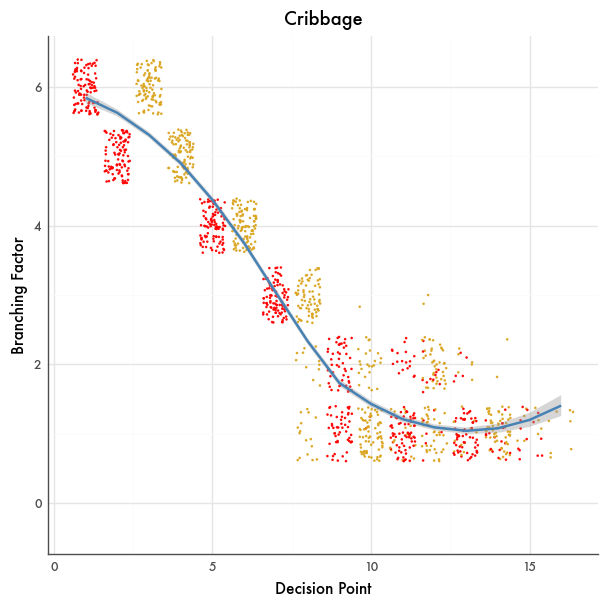

In [90]:
game = "Cribbage"
choiceframe["player"] = choiceframe["player"].astype(str)
cplot = (ggplot(choiceframe[(choiceframe["ai"].str.startswith("R")) & (choiceframe["game"] == game)], aes("move", "choices", color="player"))
 + geom_jitter(size=0.05, alpha=0.9)
 + geom_smooth(method="loess", color="steelblue")
 + aes(ymin=0)
 + theme_minimal(base_family="Futura", base_size=11) 
 + theme(legend_position='none', figure_size=(6, 6))
 + theme(
        #plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + labs(x='Decision Point', y='Branching Factor', title=gameframe[gameframe["game"]==game]["name"].item())
 + scale_colour_manual(values = ("red", "goldenrod", "limegreen", "cyan", "blue", "violet"))
)
cplot.save("Choices"+game+".png")
cplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 8 x 10 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ChoicesRandom.png


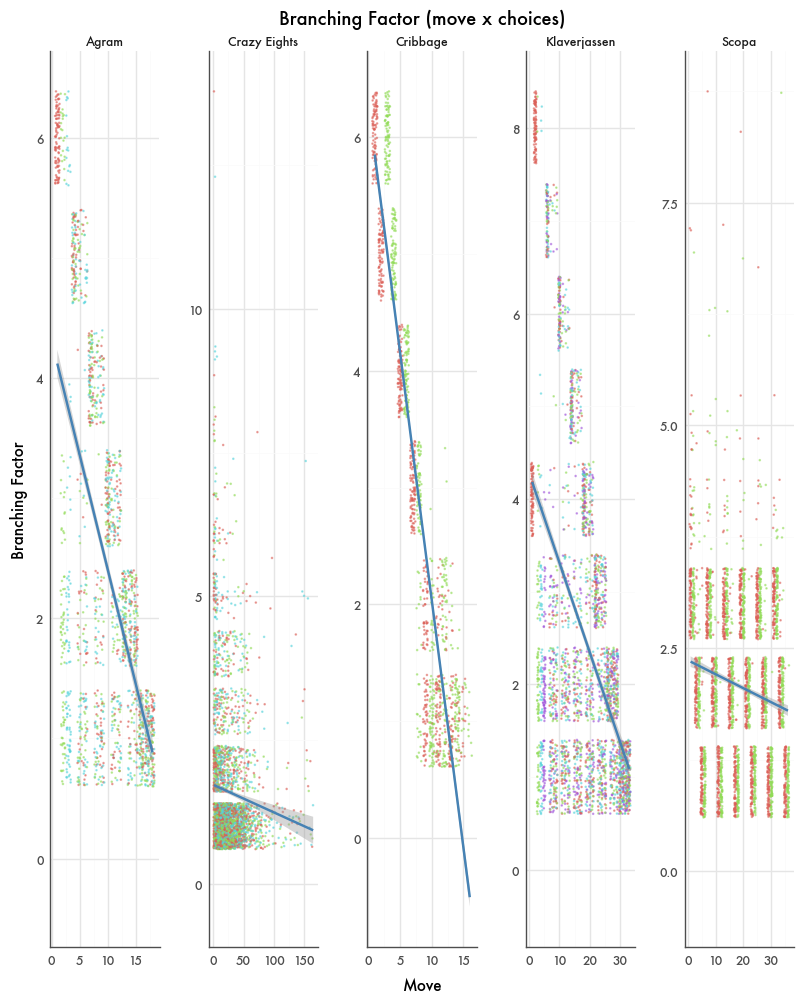

In [91]:
choiceframe["player"] = choiceframe["player"].astype(str)
cplot = (ggplot(choiceframe[choiceframe["ai"].str.startswith("R")], aes("move", "choices", color="player"))
 + geom_jitter(size=0.05, alpha=0.5)
 + geom_smooth(method="lm", color="steelblue")
 + facet_wrap("name", scales = "free", ncol = 5)
 + aes(ymin=0)
 + theme_minimal(base_family="Futura", base_size=11) 
 + theme(legend_position='none', figure_size=(8, 10))
 + theme(
#        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
 #       axis_title=element_blank(),
        panel_spacing=0.03,
     
    )
 + labs(x='Move', y='Branching Factor', title="Branching Factor (move x choices)")
)
cplot.save("ChoicesRandom.png")
cplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: AllChoicesRandom.png


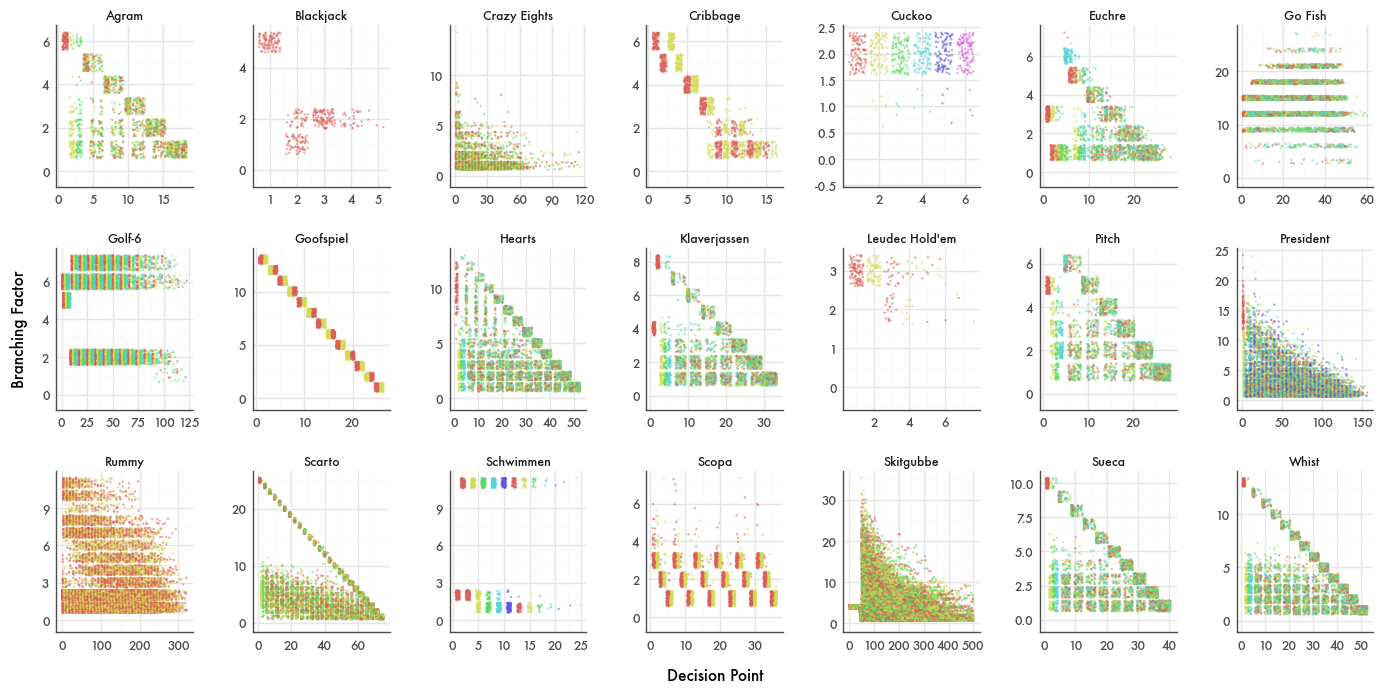

In [9]:
choiceframe["player"] = choiceframe["player"].astype(str)
cplot = (ggplot(choiceframe[choiceframe["ai"].str.startswith("R")], aes("move", "choices", color="player"))
 + geom_jitter(size=0.05, alpha=0.4)
 + facet_wrap("name", scales = "free", ncol = 7)
 + aes(ymin=0)
 + theme_minimal(base_family="Futura", base_size=11) 
 + theme(legend_position='none', figure_size=(14, 7))
 + theme(
#        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        #axis_title=element_blank(),
        panel_spacing=0.02,
     
    )
 + labs(x='Decision Point', y='Branching Factor')

)
cplot.save("AllChoicesRandom.png")
cplot.show()

This plot is the branching factor for the PIPMC players

In [8]:
choiceframe["player"] = choiceframe["player"].astype(str)
cplot = (ggplot(choiceframe[choiceframe["ai"].str.startswith("P")], aes("move", "choices", color="player"))
 + geom_jitter(size=0.05, alpha=0.5)
 + geom_smooth(method="loess", color="steelblue")
 + facet_wrap("game", scales = "free", ncol = 7)
 + aes(ymin=0)
 + theme_minimal(base_family="Futura", base_size=11) 
 + theme(legend_position='none', figure_size=(14, 14))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='Move', y='Branching Factor', title="Branching Factor (move x choices)")
)
cplot.save("ChoicesPIPMC.png")
cplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 14 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ChoicesPIPMC.png


ValueError: b'There are other near singularities as well. 1\n'

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 8 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: ChoicesMCTS.png


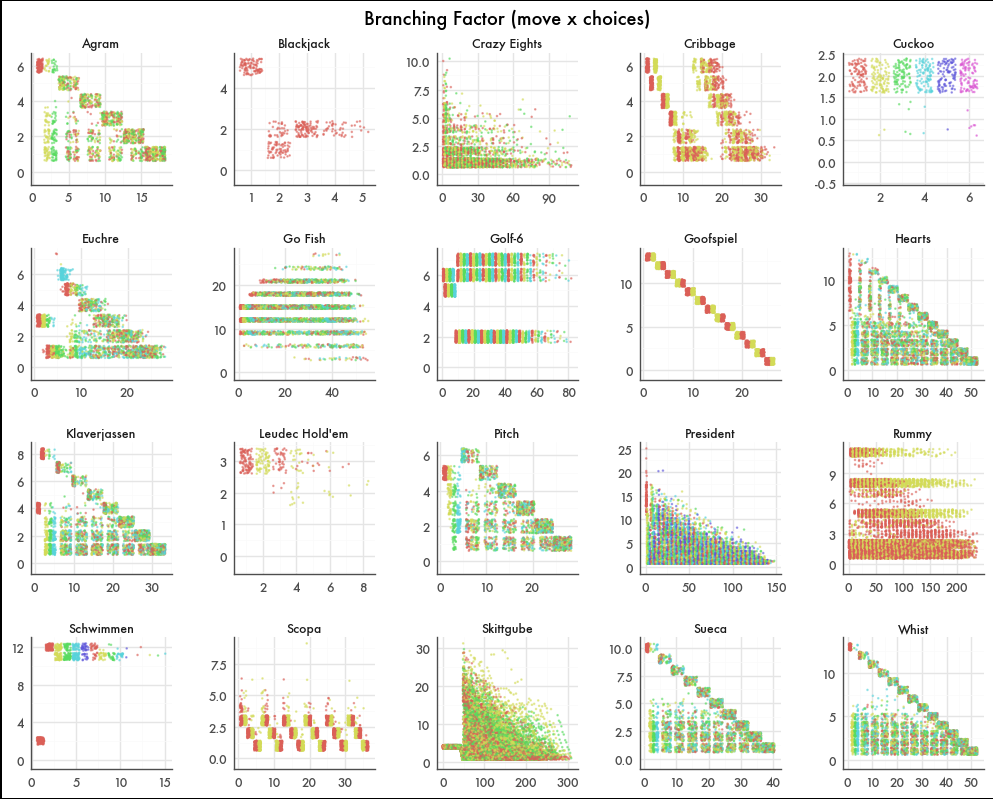

In [30]:
choiceframe["player"] = choiceframe["player"].astype(str)
cplot = (ggplot(choiceframe[choiceframe["ai"].str.startswith("M")], aes("move", "choices", color="player"))
 + geom_jitter(size=0.05, alpha=0.5)
 + facet_wrap("name", scales = "free", ncol = 5)
 + aes(ymin=0)
 + theme_minimal(base_family="Futura", base_size=11) 
 + theme(legend_position='none', figure_size=(10, 8))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='Move', y='Branching Factor', title="Branching Factor (move x choices)")
)
cplot.save("ChoicesMCTS.png")
cplot.show()

And one plot that shows them all.

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 20 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Choices.png


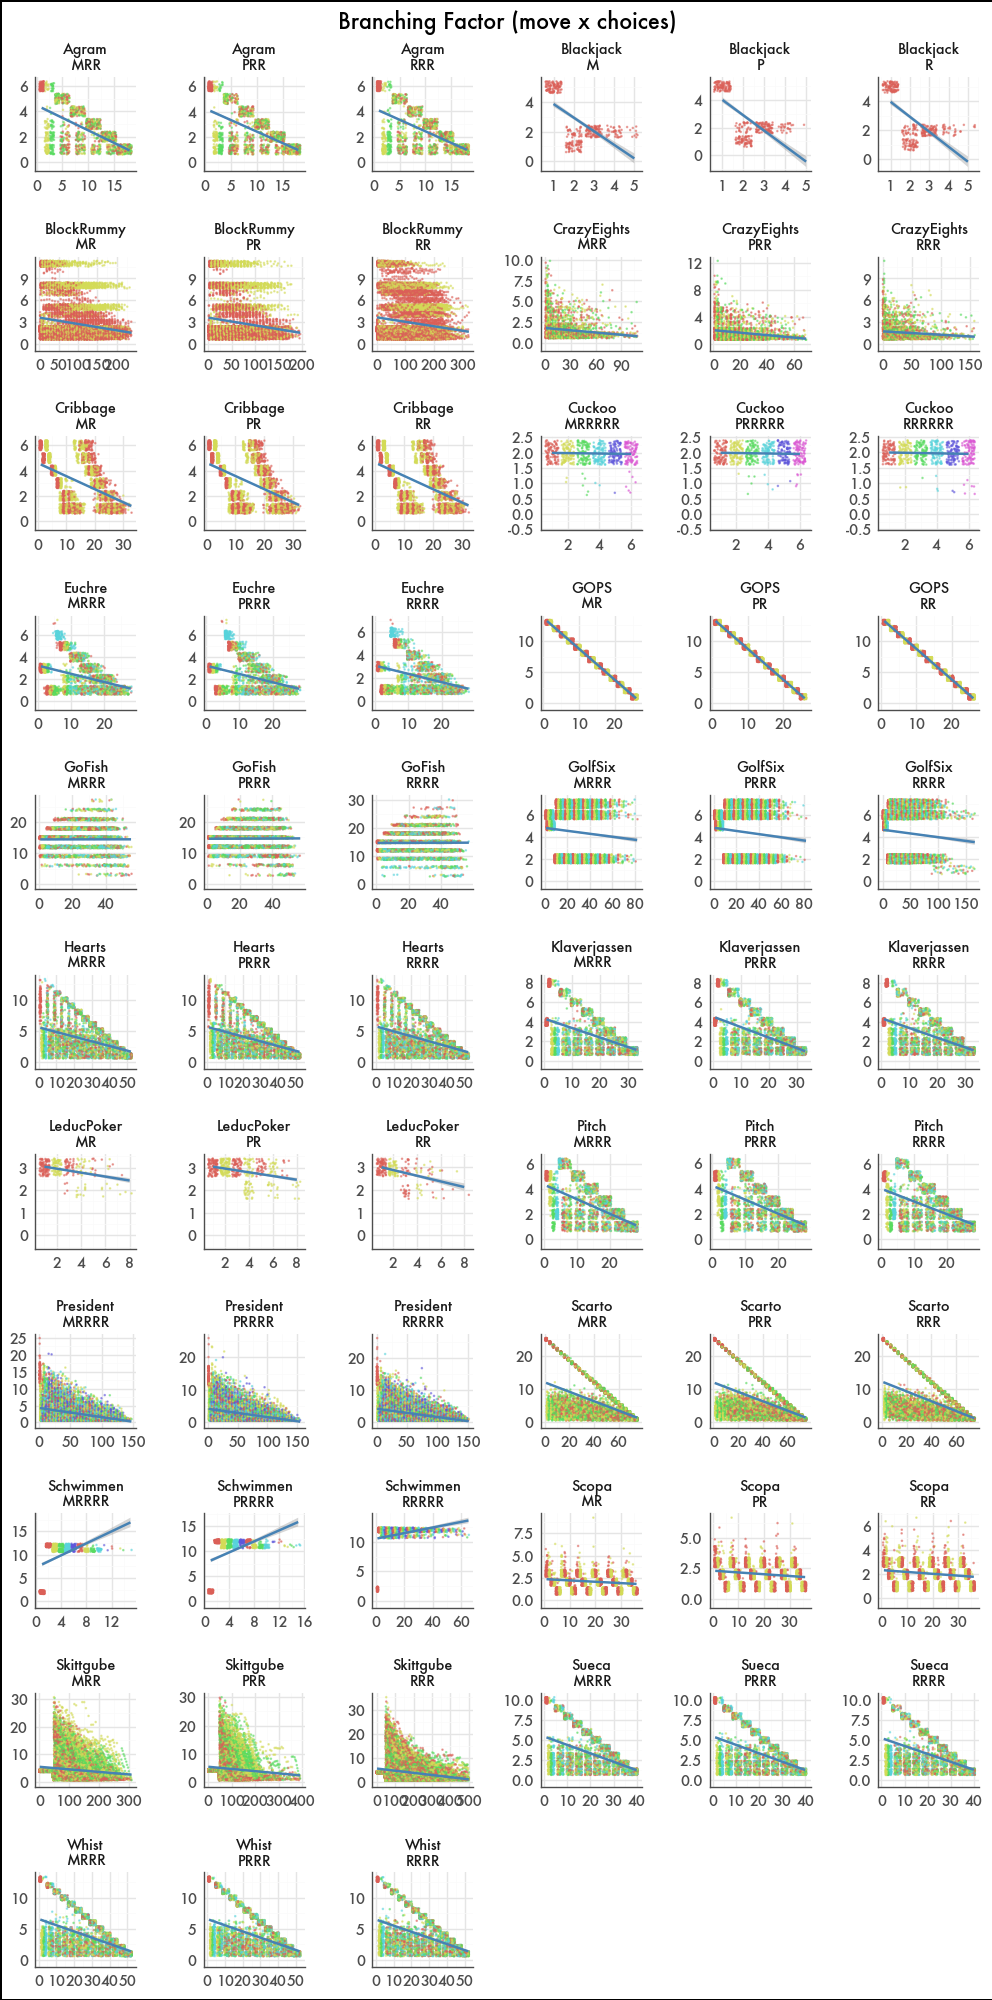

In [57]:
choiceframe["player"] = choiceframe["player"].astype(str)
cplot = (ggplot(choiceframe, aes("move", "choices", color="player"))
 + geom_jitter(size=0.05, alpha=0.5)
 + geom_smooth(method="lm", color="steelblue")
 + facet_wrap(["game", "ai"], scales = "free", ncol = 6)
 + aes(ymin=0)
 + theme_minimal(base_family="Futura", base_size=13) 
 + theme(legend_position='none', figure_size=(10, 20))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='Move', y='Branching Factor', title="Branching Factor (move x choices)")
)
cplot.save("Choices.png")
cplot.show()

# Game Length

We can calculate the average game length, by finding the max value for the move column on each run, then averaging

In [92]:
choiceframe[['game', 'run', 'move']][choiceframe["ai"].str.startswith("R")].groupby(['game', 'run'], as_index=False)['move'].max().groupby(['game'], as_index=False).mean()

,game,run,move
0,Agram,50.5,18.00
1,CrazyEights,50.5,35.09
2,Cribbage,50.5,13.85
3,Klaverjassen,50.5,33.00
4,Scopa,50.5,36.00


In [93]:
lengthframe = choiceframe[['name', 'run', 'move']][choiceframe["ai"].str.startswith("R")].groupby(['name', 'run'], as_index=False)['move'].max()
lengthframe

,name,run,move
0,Agram,1,18
1,Agram,2,18
2,Agram,3,18
3,Agram,4,18
4,Agram,5,18
...,...,...,...
495,Scopa,96,36
496,Scopa,97,36
497,Scopa,98,36
498,Scopa,99,36


/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 5 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: LengthM.png


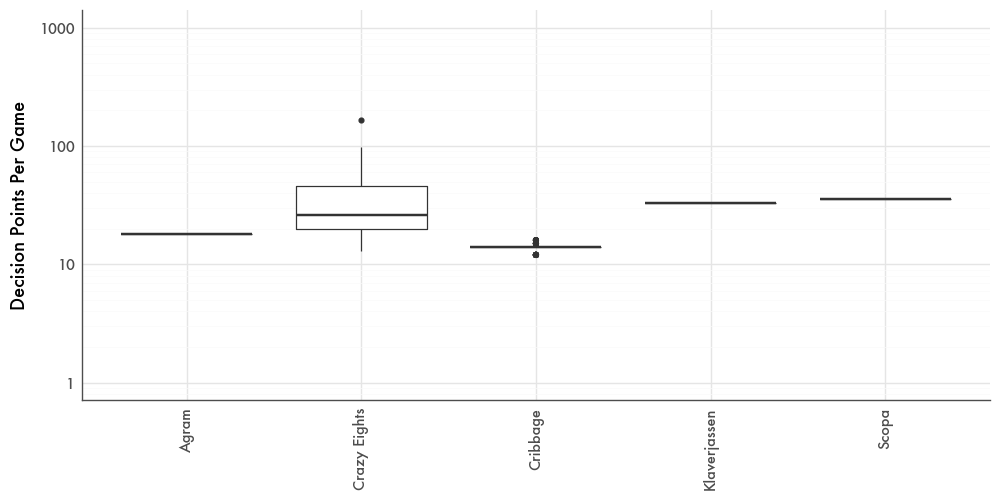

In [94]:
lplot = (ggplot(lengthframe, aes("name", "move"))
 + geom_boxplot()
 + theme_minimal(base_family="Futura", base_size=13) 
 + theme(legend_position='none', figure_size=(10, 5))
 + theme(
        axis_text_x=element_text(rotation=90),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + scale_y_log10(limits=(1, 1000))        
 + labs(y="Decision Points Per Game", x="")
)
lplot.save("LengthM.png")
lplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 5 x 5 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: LengthCrazy Eights.png


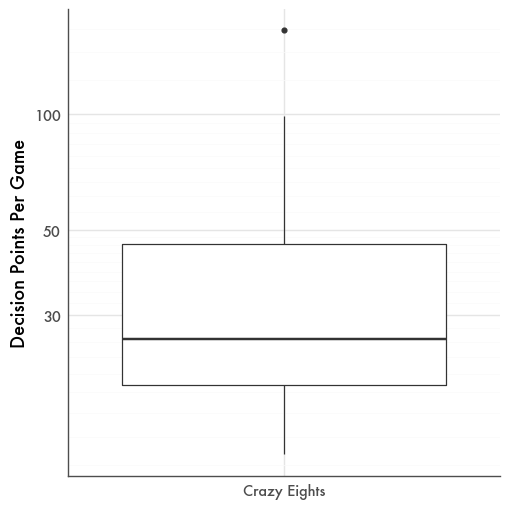

In [95]:
game = "Crazy Eights"
lplot = (ggplot(lengthframe[lengthframe["name"]==game], aes("name", "move"))
 + geom_boxplot()
 + theme_minimal(base_family="Futura", base_size=13) 
 + theme(legend_position='none', figure_size=(5, 5))
 + theme(
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + scale_y_log10() 
 + labs(y="Decision Points Per Game", x="")
)
lplot.save("Length"+ game +".png")
lplot.show()

In [96]:
lengthf = choiceframe[['game', 'run', 'move']][choiceframe["ai"].str.startswith("R")].groupby(['game', 'run'], as_index=False)['move'].max().groupby(['game'], as_index=False).mean()[['game', 'move']]
gameframe = gameframe.merge(lengthf, on='game', how='left')

In [97]:
gameframe

,game,name,player,fileprefix,convergence,move
0,Agram,Agram,3,../CardStock/output/Valet/,0.594787,18.00
1,CrazyEights,Crazy Eights,3,../CardStock/output/Valet/,0.529805,35.09
2,Cribbage,Cribbage,2,../CardStock/output/Valet/,0.717848,13.85
3,Klaverjassen,Klaverjassen,4,../CardStock/output/Valet/,0.548429,33.00
4,Scopa,Scopa,2,../CardStock/output/Valet/,0.507857,36.00


# Results

For random games, we want to look at the distribution of win/loss percentages across the players.

In [98]:
first = True
for index, row in gameframe.iterrows():
    print(row["game"])
    gf = pd.read_csv(row["fileprefix"] + row["game"] + "/" + str(row["player"]) + "/" + "R" * row["player"] + "/results.csv")
    if row["game"] == "Schwimmen":
        gf["score"] = gf["score"] / 2.0
    gf["game"] = row["game"]
    gf["name"] = row["name"]
    gf["ai"] = "Random"
    if first:
        resultsframe = gf
        first = False
    else:
        resultsframe = pd.concat([resultsframe, gf])
    gf = pd.read_csv(row["fileprefix"] + row["game"] + "/" + str(row["player"]) + "/" + "M" + "R" * (row["player"] - 1) + "/results.csv")
    if row["game"] == "Schwimmen":
        gf["score"] = gf["score"] / 2.0
    gf["game"] = row["game"]
    gf["name"] = row["name"]
    gf["ai"] = "MCTS"
    resultsframe = pd.concat([resultsframe, gf])
#    gf = pd.read_csv(row["fileprefix"] + row["game"] + "/" + str(row["player"]) + "/" + "P" + "R" * (row["player"] - 1) + "/results.csv")
#    if row["game"] == "Schwimmen":
#        gf["score"] = gf["score"] / 2.0
#    gf["game"] = row["game"]
#    gf["name"] = row["name"]
#    gf["ai"] = "PIPMC"
#    resultsframe = pd.concat([resultsframe, gf])

resultsframe["player"] = resultsframe["player"].astype(str)
resultsframe["rank"] = resultsframe["rank"].astype(str)
resultsframe

Agram
CrazyEights
Cribbage
Klaverjassen
Scopa


,game,numPlayers,ai,imperfect,samples,tests,run,player,score,rank,time,name
0,Agram,3,Random,PRIVATE,10,1000,1,1,0,2,22.9586,Agram
1,Agram,3,Random,PRIVATE,10,1000,1,2,1,1,22.9586,Agram
2,Agram,3,Random,PRIVATE,10,1000,1,3,0,2,22.9586,Agram
3,Agram,3,Random,PRIVATE,10,1000,2,1,0,2,2.8518,Agram
4,Agram,3,Random,PRIVATE,10,1000,2,2,0,2,2.8518,Agram
...,...,...,...,...,...,...,...,...,...,...,...,...
195,Scopa,2,MCTS,PRIVATE,10,1000,98,2,1,2,24749.2111,Scopa
196,Scopa,2,MCTS,PRIVATE,10,1000,99,1,5,1,24834.1454,Scopa
197,Scopa,2,MCTS,PRIVATE,10,1000,99,2,1,2,24834.1454,Scopa
198,Scopa,2,MCTS,PRIVATE,10,1000,100,1,4,1,25887.0931,Scopa


# Timing

In [99]:
pgames = resultsframe[['name', 'run', 'ai', 'time']]
what = pgames.groupby(['name', 'run', 'ai'], as_index=False)['time'].max()
timef = what.groupby(['name', 'ai'], as_index=False).median()[['name', 'time', 'ai']]
timef

,name,time,ai
0,Agram,5231.03250,MCTS
1,Agram,2.62530,Random
2,Crazy Eights,13719.88175,MCTS
3,Crazy Eights,3.76980,Random
4,Cribbage,11349.44485,MCTS
5,Cribbage,1.93505,Random
6,Klaverjassen,42323.97975,MCTS
7,Klaverjassen,4.20870,Random
8,Scopa,25855.29120,MCTS
9,Scopa,3.64280,Random


/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 8 x 5 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Time.png


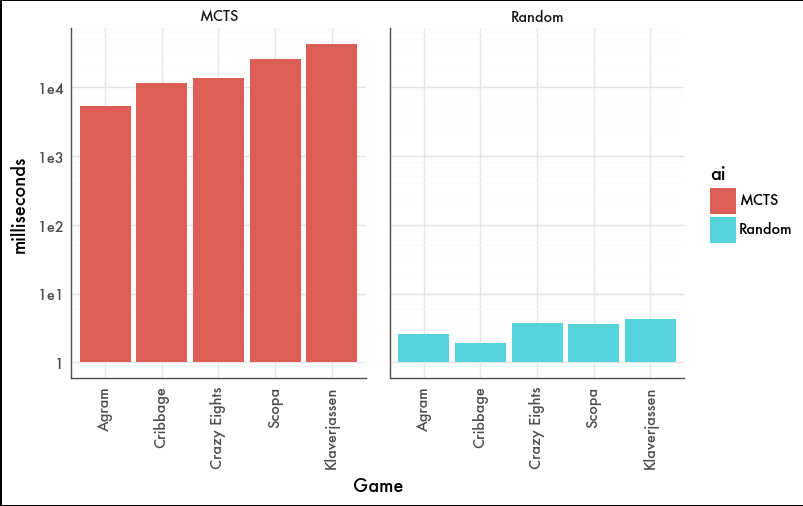

In [100]:
rplot = (ggplot(timef, aes("reorder(name, time)", "time", fill="ai"))
 + geom_bar(position="dodge", stat="identity")
 + facet_wrap(["ai"])
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(8, 5))
 + theme(
        axis_text_x=element_text(rotation=90),
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + labs(x='Game', y='milliseconds')
 + scale_y_log10()
)
rplot.save("Time.png")
rplot.show()

In [101]:
rf2 = resultsframe.groupby(['name', 'player', 'rank', 'ai'], as_index=False).count()
rf3 = rf2[(rf2["player"]=="1") & (rf2["rank"] == "1")][["name", "ai", "run"]]
rf3["run"] = rf3["run"] / 100
rf4 = rf3.pivot(index='name', columns='ai')
rf4 = rf4["run"].reset_index()
rf4.columns.name=None
rf5 = rf4.merge(gameframe, on='name', how='left')
rf5

,name,MCTS,Random,game,player,fileprefix,convergence,move
0,Agram,0.49,0.25,Agram,3,../CardStock/output/Valet/,0.594787,18.00
1,Crazy Eights,0.45,0.39,CrazyEights,3,../CardStock/output/Valet/,0.529805,35.09
2,Cribbage,0.91,0.81,Cribbage,2,../CardStock/output/Valet/,0.717848,13.85
3,Klaverjassen,0.79,0.56,Klaverjassen,4,../CardStock/output/Valet/,0.548429,33.00
4,Scopa,0.87,0.61,Scopa,2,../CardStock/output/Valet/,0.507857,36.00


In [102]:
def fairness(wp, np):
    if np == 1:
        return 1
    if wp < 1 / np:
        return wp * np
    else:
        return (np - np * wp) / (np - 1)
rf5["fairness"] = rf5.apply(lambda x: fairness(x.Random, x.player), axis=1)
def order(aiwp, np):
    if np == 1:
        return 1
    ewp = 1 / np
    return (aiwp - ewp) / (1 - ewp)
rf5["order"] = rf5.apply(lambda x: order(x.MCTS, x.player), axis=1)
rf5["gain"] = rf5.apply(lambda x: x.MCTS - x.Random, axis=1)
rf5

,name,MCTS,Random,game,player,fileprefix,convergence,move,fairness,order,gain
0,Agram,0.49,0.25,Agram,3,../CardStock/output/Valet/,0.594787,18.00,0.750000,0.235,0.24
1,Crazy Eights,0.45,0.39,CrazyEights,3,../CardStock/output/Valet/,0.529805,35.09,0.915000,0.175,0.06
2,Cribbage,0.91,0.81,Cribbage,2,../CardStock/output/Valet/,0.717848,13.85,0.380000,0.820,0.10
3,Klaverjassen,0.79,0.56,Klaverjassen,4,../CardStock/output/Valet/,0.548429,33.00,0.586667,0.720,0.23
4,Scopa,0.87,0.61,Scopa,2,../CardStock/output/Valet/,0.507857,36.00,0.780000,0.740,0.26


In [103]:
gameframe = gameframe.merge(rf5[["name", "fairness", "order", "gain", "MCTS"]], on="name", how="left")

In [104]:
gameframe

,game,name,player,fileprefix,convergence,move,fairness,order,gain,MCTS
0,Agram,Agram,3,../CardStock/output/Valet/,0.594787,18.00,0.750000,0.235,0.24,0.49
1,CrazyEights,Crazy Eights,3,../CardStock/output/Valet/,0.529805,35.09,0.915000,0.175,0.06,0.45
2,Cribbage,Cribbage,2,../CardStock/output/Valet/,0.717848,13.85,0.380000,0.820,0.10,0.91
3,Klaverjassen,Klaverjassen,4,../CardStock/output/Valet/,0.548429,33.00,0.586667,0.720,0.23,0.79
4,Scopa,Scopa,2,../CardStock/output/Valet/,0.507857,36.00,0.780000,0.740,0.26,0.87


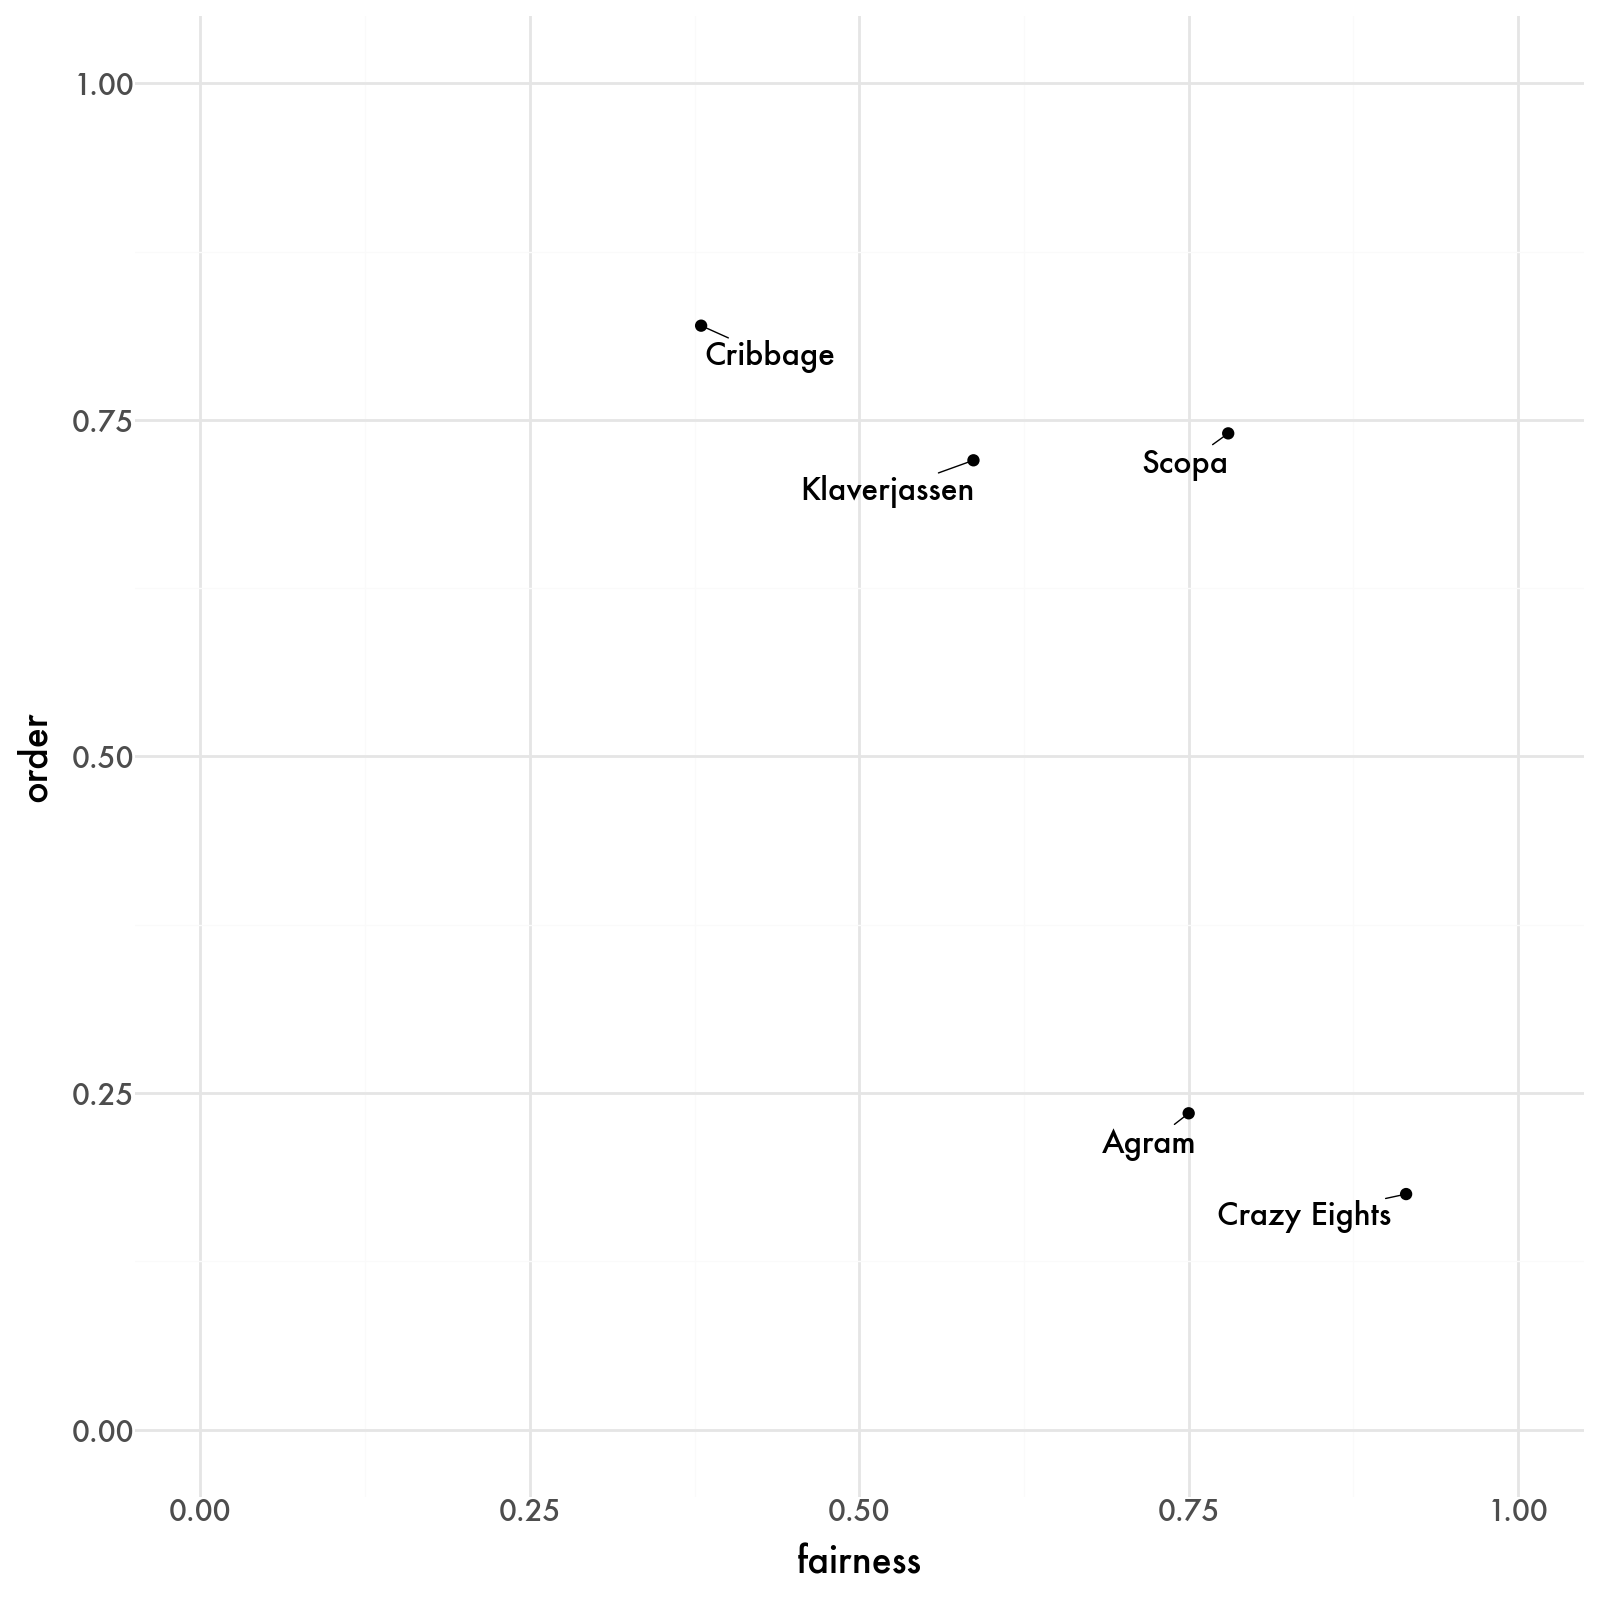

In [108]:
(ggplot(gameframe, aes("fairness", "order", label="name"))
 + geom_point()
 + xlim(0, 1)
 + ylim(0, 1)
 + geom_text(adjust_text={"arrowprops": {"arrowstyle": "-"}})
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(8, 8))
)

In [109]:
rf6 = rf3.merge(gameframe[["game", "name", "gain", "player"]], on='name', how='left')
rf6.sort_values(by=['gain'])

,name,ai,run,game,gain,player
2,Crazy Eights,MCTS,0.45,CrazyEights,0.06,3
3,Crazy Eights,Random,0.39,CrazyEights,0.06,3
4,Cribbage,MCTS,0.91,Cribbage,0.10,2
5,Cribbage,Random,0.81,Cribbage,0.10,2
6,Klaverjassen,MCTS,0.79,Klaverjassen,0.23,4
7,Klaverjassen,Random,0.56,Klaverjassen,0.23,4
0,Agram,MCTS,0.49,Agram,0.24,3
1,Agram,Random,0.25,Agram,0.24,3
8,Scopa,MCTS,0.87,Scopa,0.26,2
9,Scopa,Random,0.61,Scopa,0.26,2


/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 5 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Ranks.png


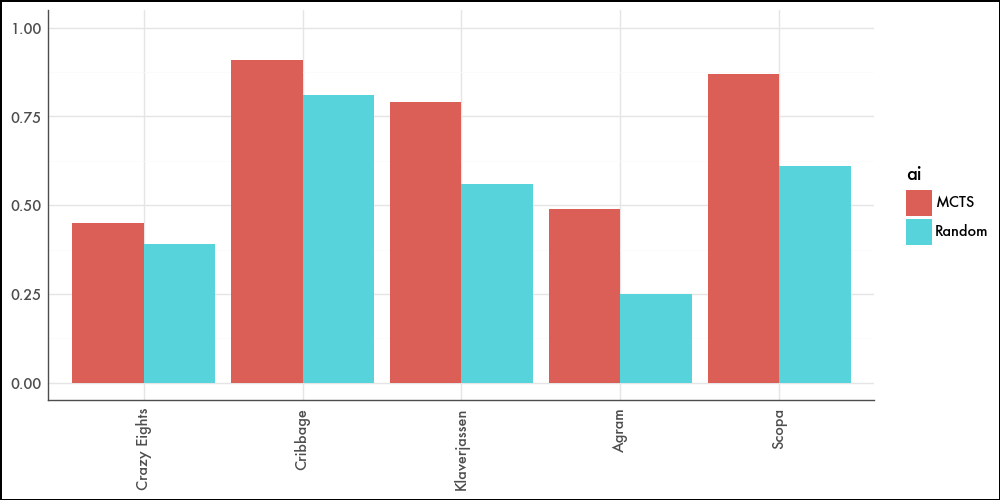

In [110]:
rplot = (ggplot(rf6, aes('reorder(name, gain)', "run", fill="ai"))
 + geom_bar(position="dodge", stat="identity")
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(10, 5))
 + theme(
        axis_text_x=element_text(rotation=90),
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + ylim(0, 1)
 + labs(x='player', y='rank')
)
rplot.save("Ranks.png")
rplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 14 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: AIBarRanks.png


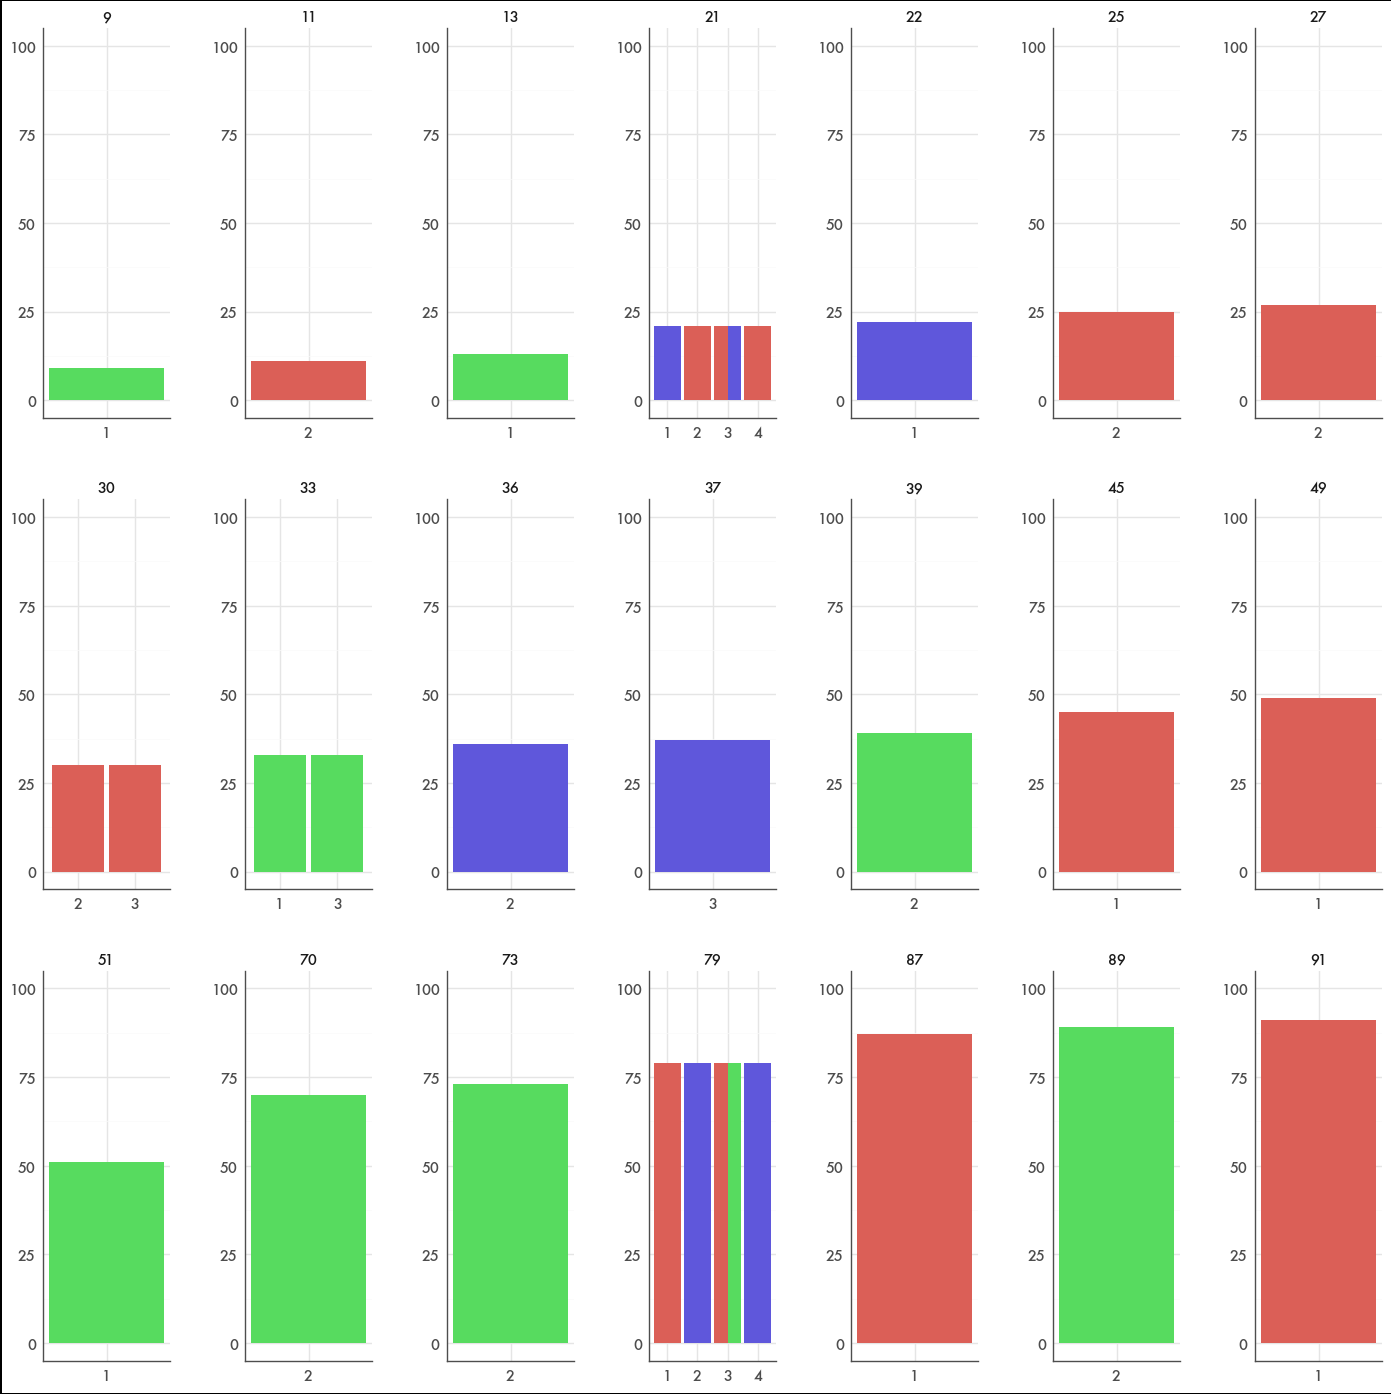

In [111]:
rplot = (ggplot(rf2[rf2["ai"]=="MCTS"], aes("player", "run", fill="rank"))
 + geom_bar(position="dodge", stat="identity")
 + facet_wrap("game", scales = "free", ncol=7)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 14))
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + ylim(0, 100)
 + labs(x='player', y='rank')
)
rplot.save("AIBarRanks.png")
rplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 8 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: RandomScores.png


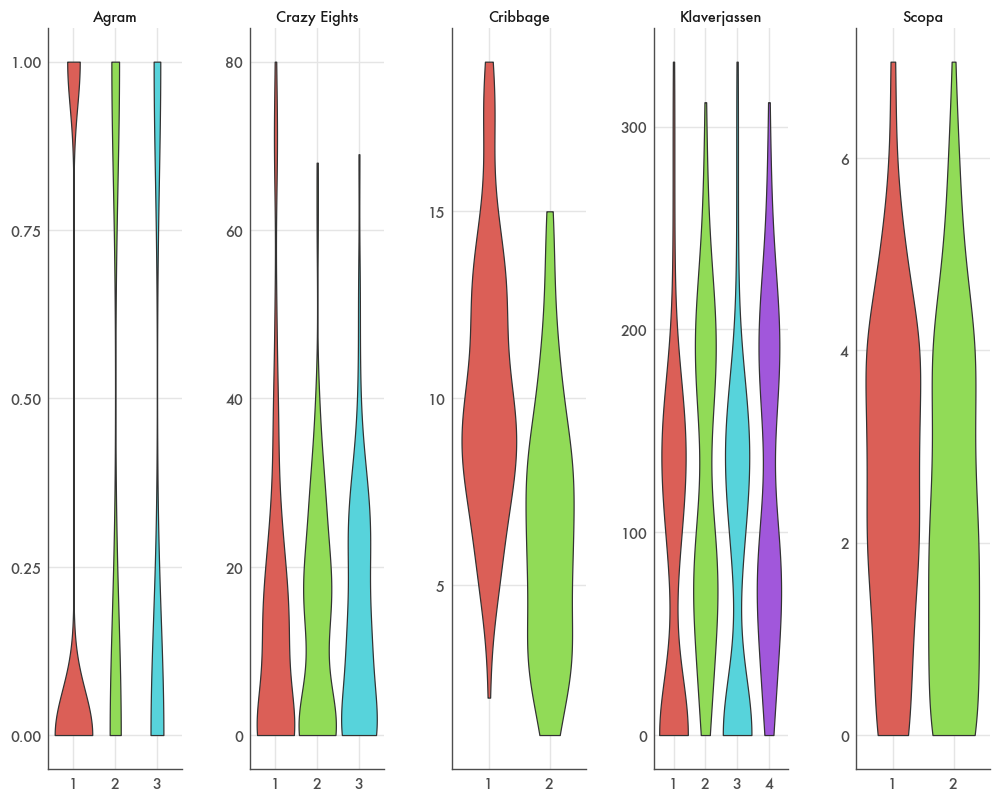

In [112]:
splot = (ggplot(resultsframe[resultsframe["ai"].str.startswith("R")], aes("player", "score", fill="player"))
 + geom_violin()
 + facet_wrap("name", scales = "free", ncol=5)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(10, 8))
 + theme(
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='player', y='rank')
 + scale_y_continuous(minor_breaks=False)
)
splot.save("RandomScores.png")
splot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 12 x 6 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: RAgramScores.png


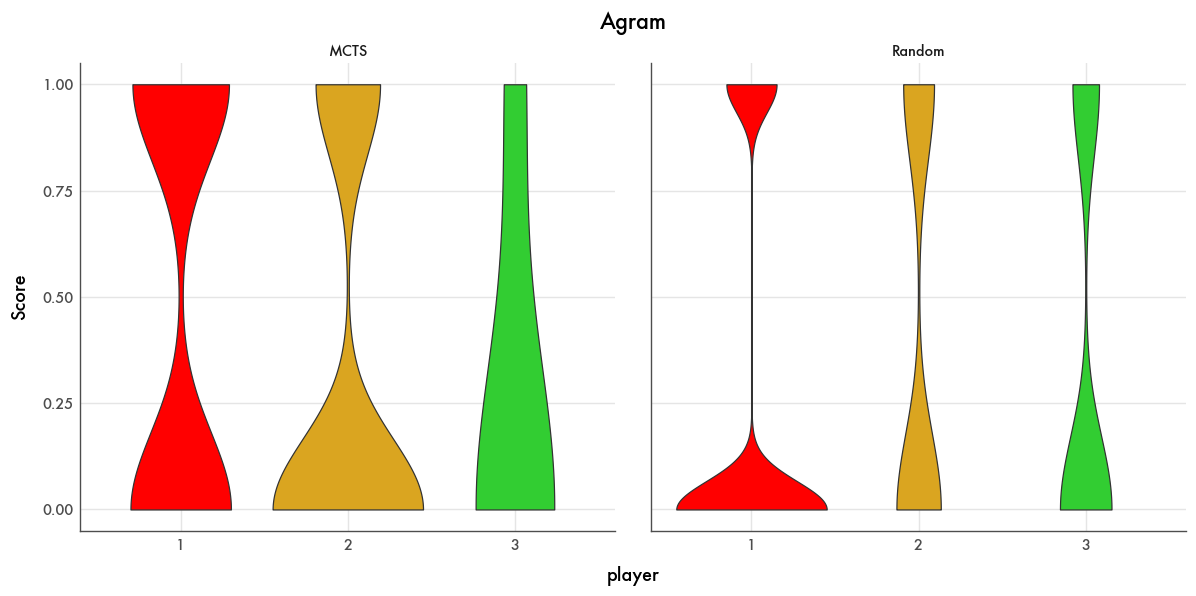

In [114]:
game = "Agram"
ai = "R"
splot = (ggplot(resultsframe[(resultsframe["game"] == game)], aes("player", "score", fill="player"))
 + geom_violin()
 + facet_wrap("ai")
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(12, 6))
 + theme(
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        #axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='player', y='Score', title=gameframe[gameframe["game"]==game]["name"].item())
 + scale_y_continuous(minor_breaks=False)
 + scale_fill_manual(values = ("red", "goldenrod", "limegreen", "cyan", "blue", "violet"))
)
splot.save(ai + game + "Scores.png")
splot.show()

In [115]:
resultsframe[(resultsframe["ai"].str.startswith(ai)) & (resultsframe["game"] == game)& (resultsframe["player"] == "2")]["score"]

1      1
4      0
7      0
10     0
13     0
      ..
286    0
289    0
292    0
295    0
298    1
Name: score, Length: 100, dtype: int64

In [116]:
resultsframe

,game,numPlayers,ai,imperfect,samples,tests,run,player,score,rank,time,name
0,Agram,3,Random,PRIVATE,10,1000,1,1,0,2,22.9586,Agram
1,Agram,3,Random,PRIVATE,10,1000,1,2,1,1,22.9586,Agram
2,Agram,3,Random,PRIVATE,10,1000,1,3,0,2,22.9586,Agram
3,Agram,3,Random,PRIVATE,10,1000,2,1,0,2,2.8518,Agram
4,Agram,3,Random,PRIVATE,10,1000,2,2,0,2,2.8518,Agram
...,...,...,...,...,...,...,...,...,...,...,...,...
195,Scopa,2,MCTS,PRIVATE,10,1000,98,2,1,2,24749.2111,Scopa
196,Scopa,2,MCTS,PRIVATE,10,1000,99,1,5,1,24834.1454,Scopa
197,Scopa,2,MCTS,PRIVATE,10,1000,99,2,1,2,24834.1454,Scopa
198,Scopa,2,MCTS,PRIVATE,10,1000,100,1,4,1,25887.0931,Scopa


In [117]:
rf2 = resultsframe[resultsframe["ai"].str.startswith("M")].groupby(['game', 'player', 'rank'], as_index=False).count()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 14 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: AIRanks.png


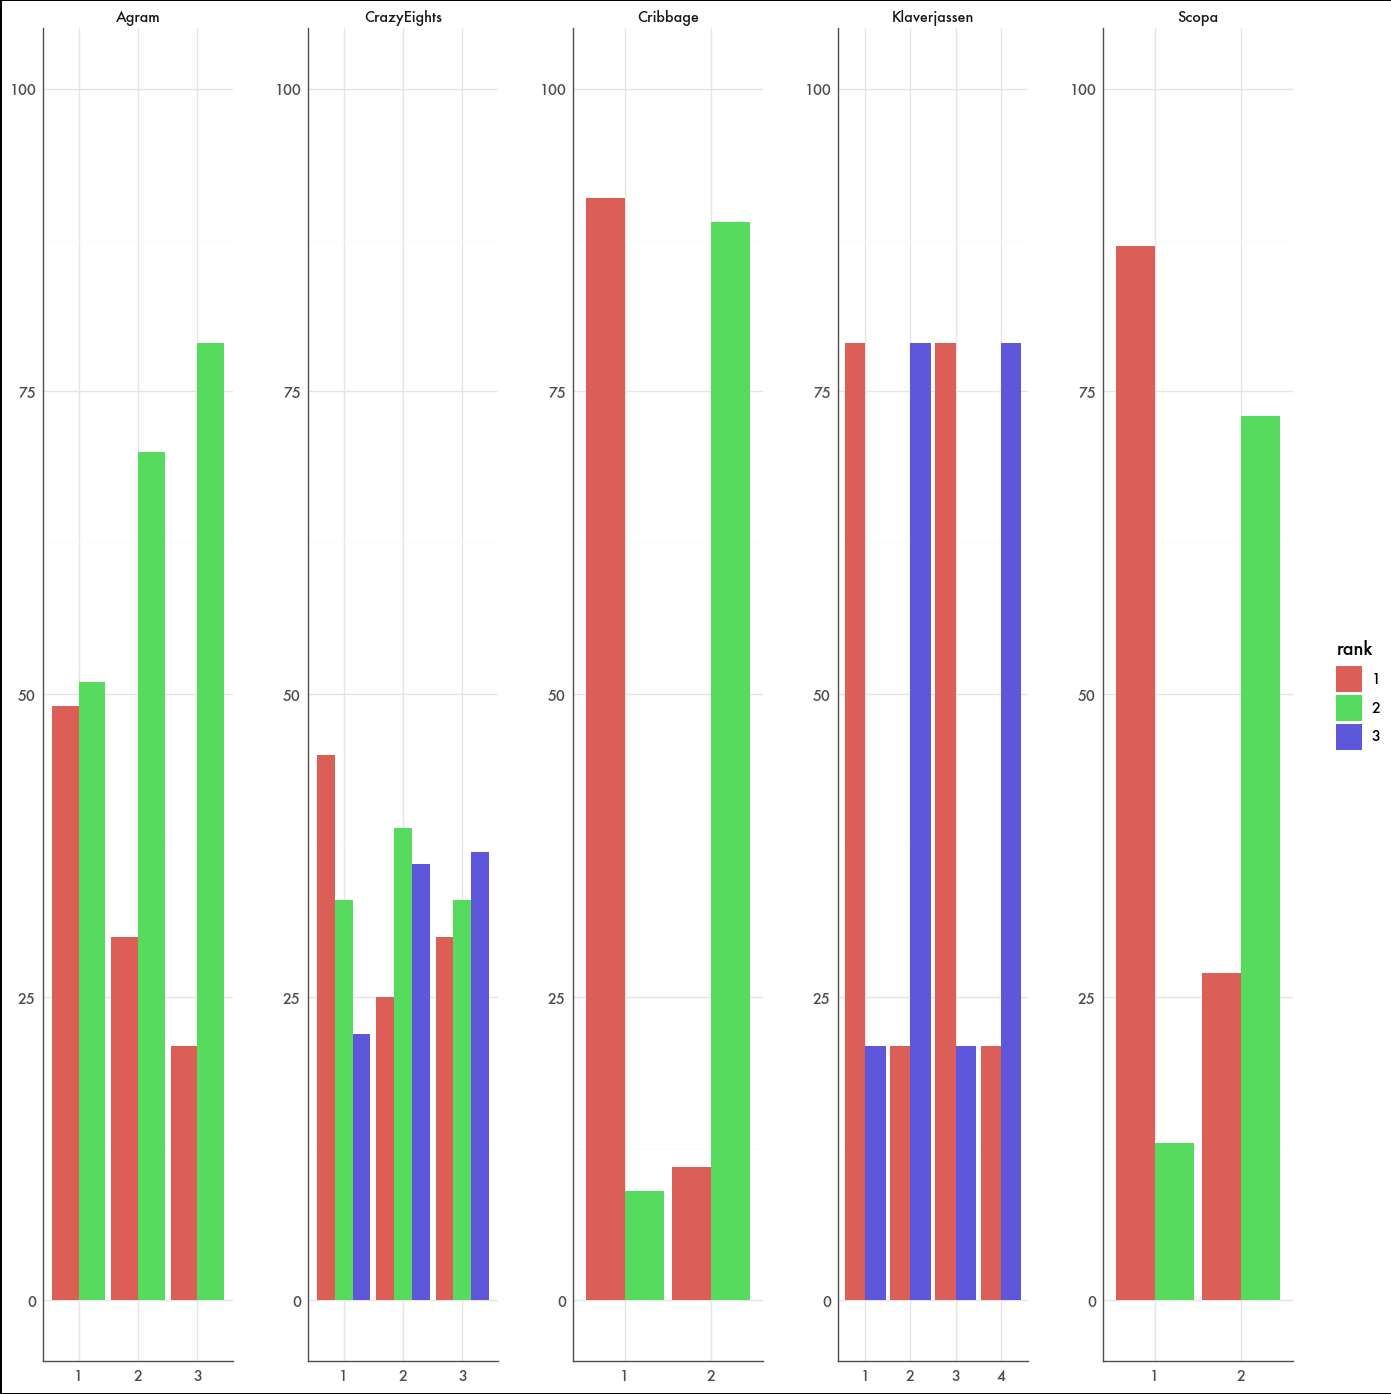

In [118]:
rplot = (ggplot(rf2, aes("player", "run", fill="rank"))
 + geom_bar(position="dodge", stat="identity")
 + facet_wrap("game", scales = "free", ncol=7)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(14, 14))
 + ylim(0, 100)
 + theme(
        plot_background=element_rect(fill="white"),
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.03,
    )
 + labs(x='player', y='rank')
)
rplot.save("AIRanks.png")
rplot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 20 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: AllScores.png


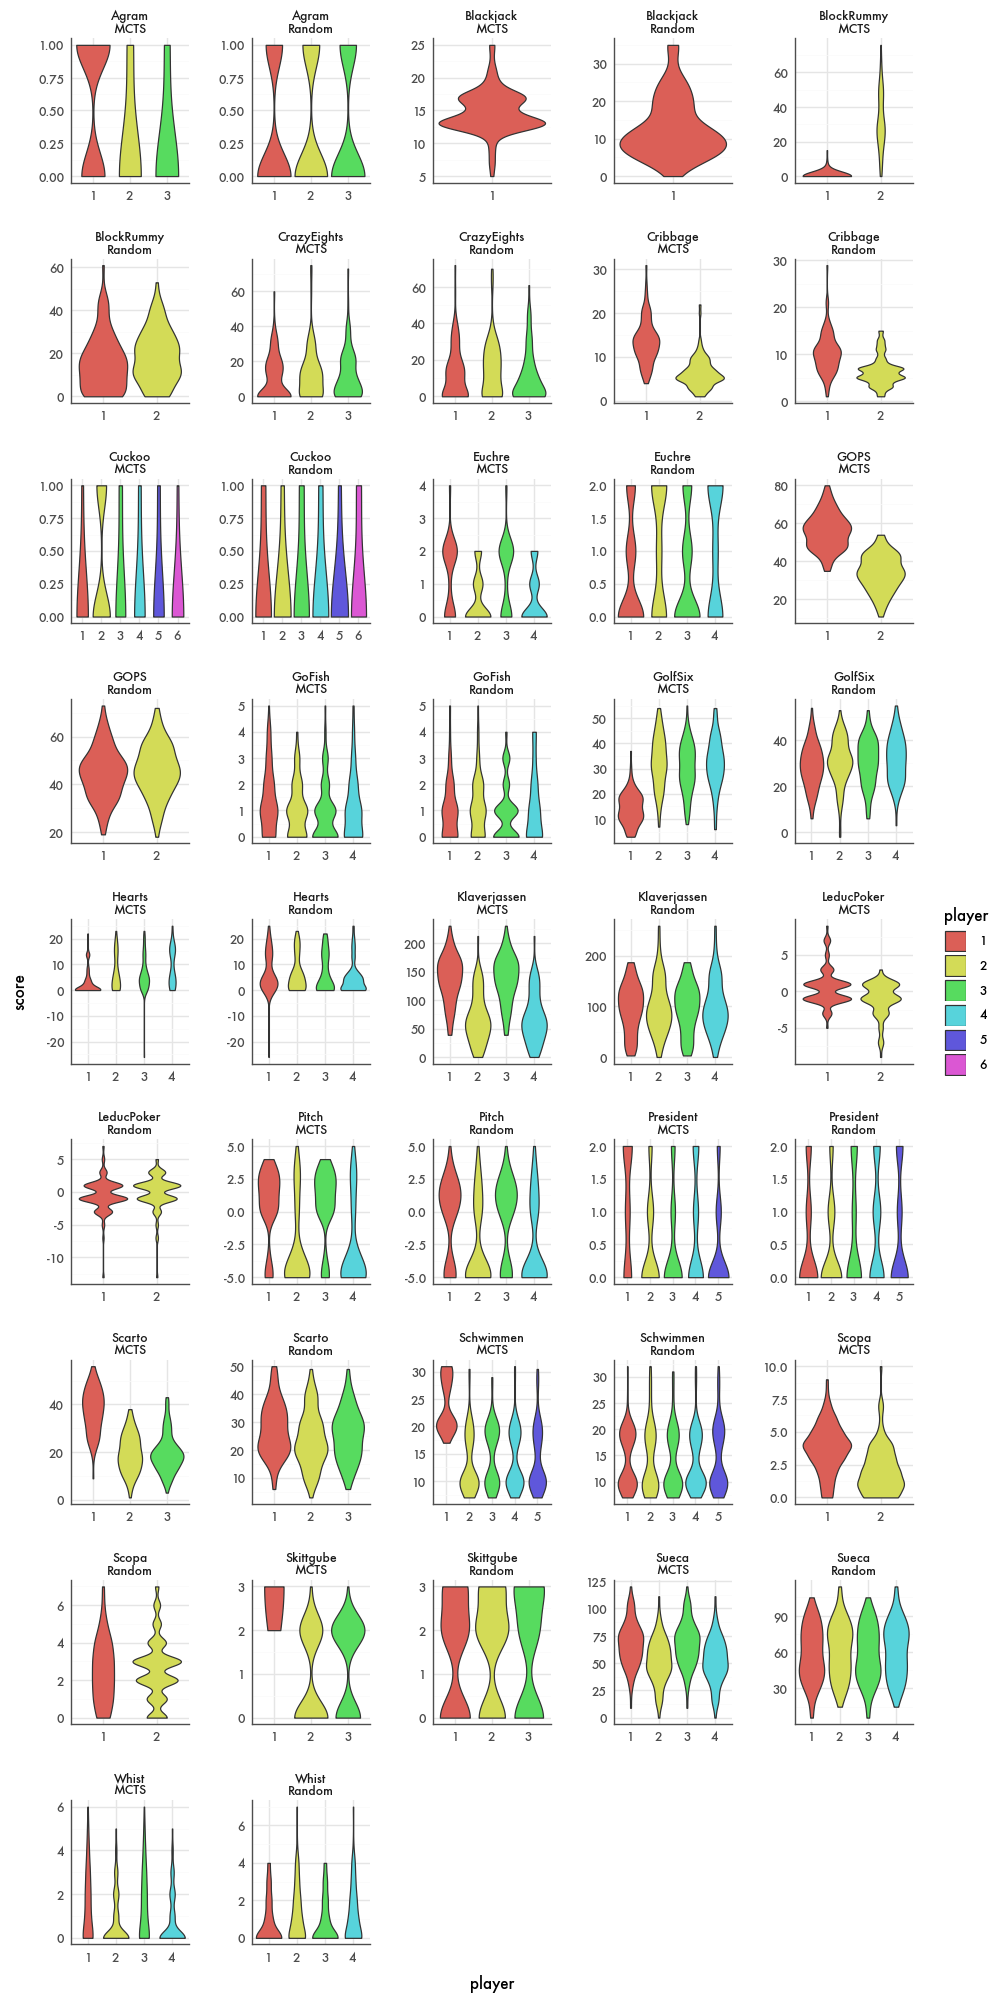

In [38]:
splot = (ggplot(resultsframe, aes("player", "score", fill="player"))
 + geom_violin()
 + facet_wrap(["game", "ai"], scales = "free", ncol = 5)
 + theme_minimal(base_family="Futura", base_size=11)
 + theme(figure_size=(10, 20))
 + theme(
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + labs(x='player', y='score')
)
splot.save("AllScores.png")
splot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 8 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: PvsRScores.png


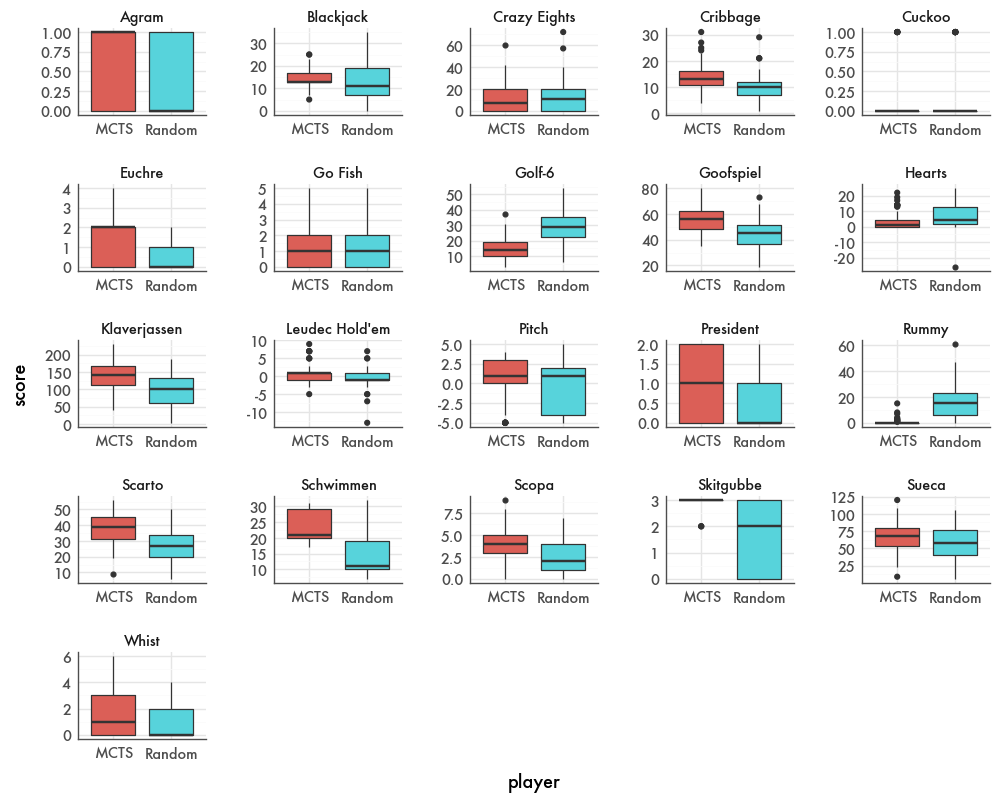

In [39]:
resultsframe["rank"] = resultsframe["rank"].astype(int)

splot = (ggplot(resultsframe[resultsframe["player"]=="1"], aes("ai", "score", fill="ai"))
 + geom_boxplot()
 + facet_wrap("name", scales = "free", ncol=5)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(10, 8))
 + theme(
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + labs(x='player', y='score')
)
splot.save("PvsRScores.png")
splot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 6 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: MvsRScores.png


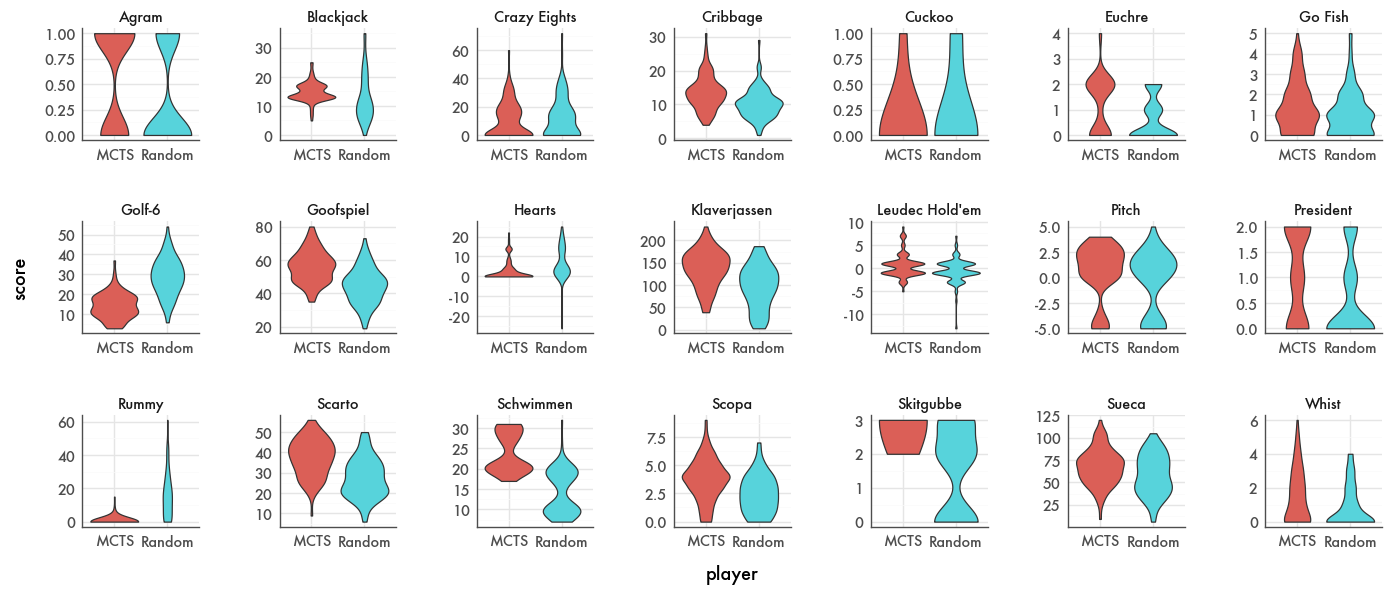

In [40]:
resultsframe["rank"] = resultsframe["rank"].astype(int)

splot = (ggplot(resultsframe[resultsframe["player"]=="1"], aes("ai", "score", fill="ai"))
 + geom_violin()
 + facet_wrap("name", scales = "free", ncol=7)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 6))
 + theme(
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        panel_spacing=0.03,
    )
 + labs(x='player', y='score')
)
splot.save("MvsRScores.png")
splot.show()

In [119]:
def sig_code(pval):
    if pval < 0.001:
        return "***"
    elif pval < 0.01:
        return "**"
    elif pval < 0.05:
        return "*"
    elif pval < 0.1:
        return "."
    else:
        return ""
comp = resultsframe[resultsframe["player"]=="1"][["game", "ai", "run", "score"]]
comp = comp.pivot(index=["game", "run"], columns="ai", values="score")
comp2 = comp.groupby("game").apply(lambda df: st.ttest_ind(df['MCTS'], df['Random'])[1]).reset_index().rename(columns={0:"p-value"})[["game", "p-value"]]
comp3 = comp.groupby('game').apply(lambda df: sig_code(st.ttest_ind(df['MCTS'], df['Random'])[1])).reset_index().rename(columns={0:"significance"})
comp4 = comp3.merge(comp2, on="game", how="left").sort_values(by="p-value")
comp4

,game,significance,p-value
2,Cribbage,***,1.828470e-09
4,Scopa,***,4.947806e-08
3,Klaverjassen,***,3.627815e-04
0,Agram,***,3.869628e-04
1,CrazyEights,*,2.251370e-02


# Spread

In [140]:
first = True
for index, row in gameframe.iterrows():
    if row["game"] != "Blackjack":
        gf = pd.read_csv(row["fileprefix"] + row["game"] + "/" + str(row["player"]) + "/" + "M" + "R" * (row["player"] - 1) + "/spread.csv")
        gf["game"] = row["game"]
        if row["game"] == "Schwimmen":
            gf["spread"] = gf["spread"] / 2.0
        if first:
            spreadframe = gf
            first = False
        else:
            spreadframe = pd.concat([spreadframe, gf])
spreadframe["player"] = spreadframe["player"].astype(str)
spreadframe["run"] = spreadframe["run"].astype(str)

In [141]:
spreadframe

,game,numPlayers,ai,imperfect,samples,tests,run,pmove,player,spread
0,Agram,3,MRR,PRIVATE,10,1000,1,1,0,0.122154
1,Agram,3,MRR,PRIVATE,10,1000,1,2,0,0.000000
2,Agram,3,MRR,PRIVATE,10,1000,1,3,0,0.105143
3,Agram,3,MRR,PRIVATE,10,1000,1,4,0,0.000000
4,Agram,3,MRR,PRIVATE,10,1000,1,5,0,0.099300
...,...,...,...,...,...,...,...,...,...,...
1795,Scopa,2,MR,PRIVATE,10,1000,100,14,0,0.125478
1796,Scopa,2,MR,PRIVATE,10,1000,100,15,0,0.000000
1797,Scopa,2,MR,PRIVATE,10,1000,100,16,0,0.749325
1798,Scopa,2,MR,PRIVATE,10,1000,100,17,0,0.462658


/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Spread.png


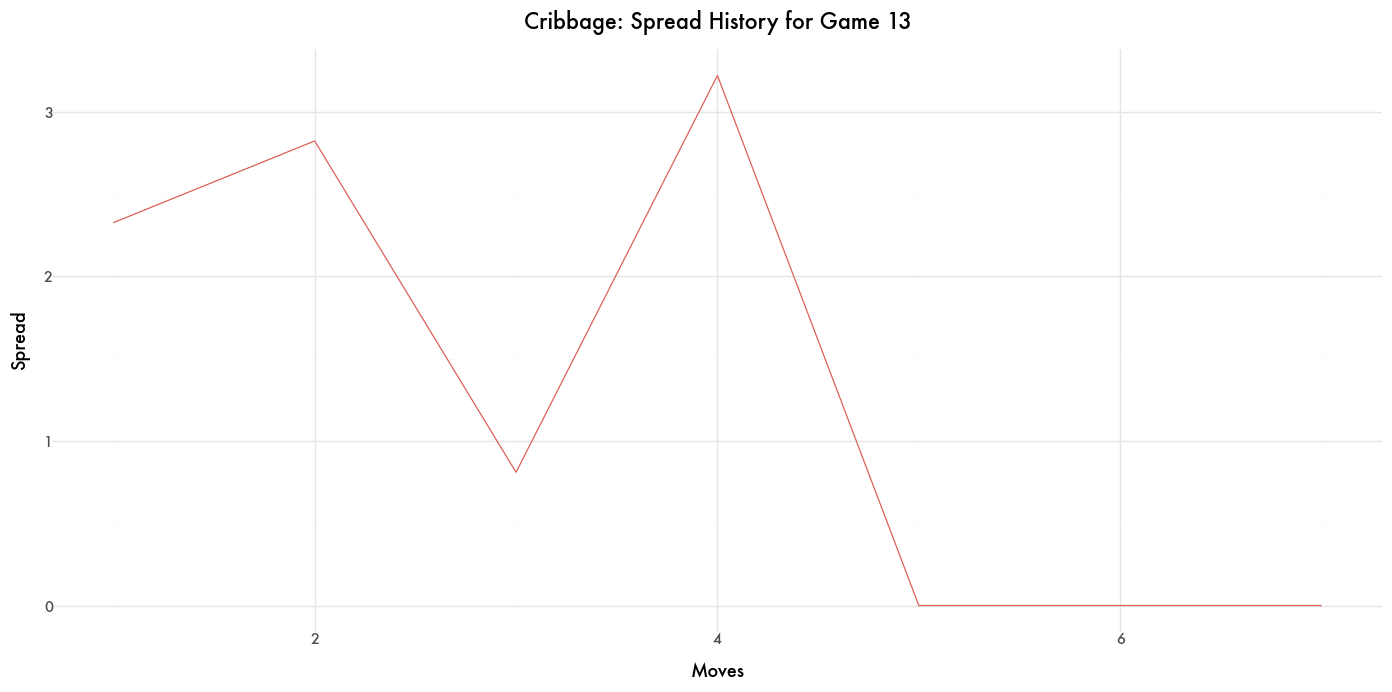

In [180]:
game = "Cribbage"
iter = "13"
splot = (ggplot(spreadframe[(spreadframe["run"] == iter) & (spreadframe["game"] == game)], 
       aes(x="pmove", y="spread", color="player"))
 + geom_line()
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 7))
 + labs(x='Moves', y='Spread', title=game + ": Spread History for Game " + str(iter))
)
splot.save("Spread.png")
splot.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 14 x 7 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Spread.png


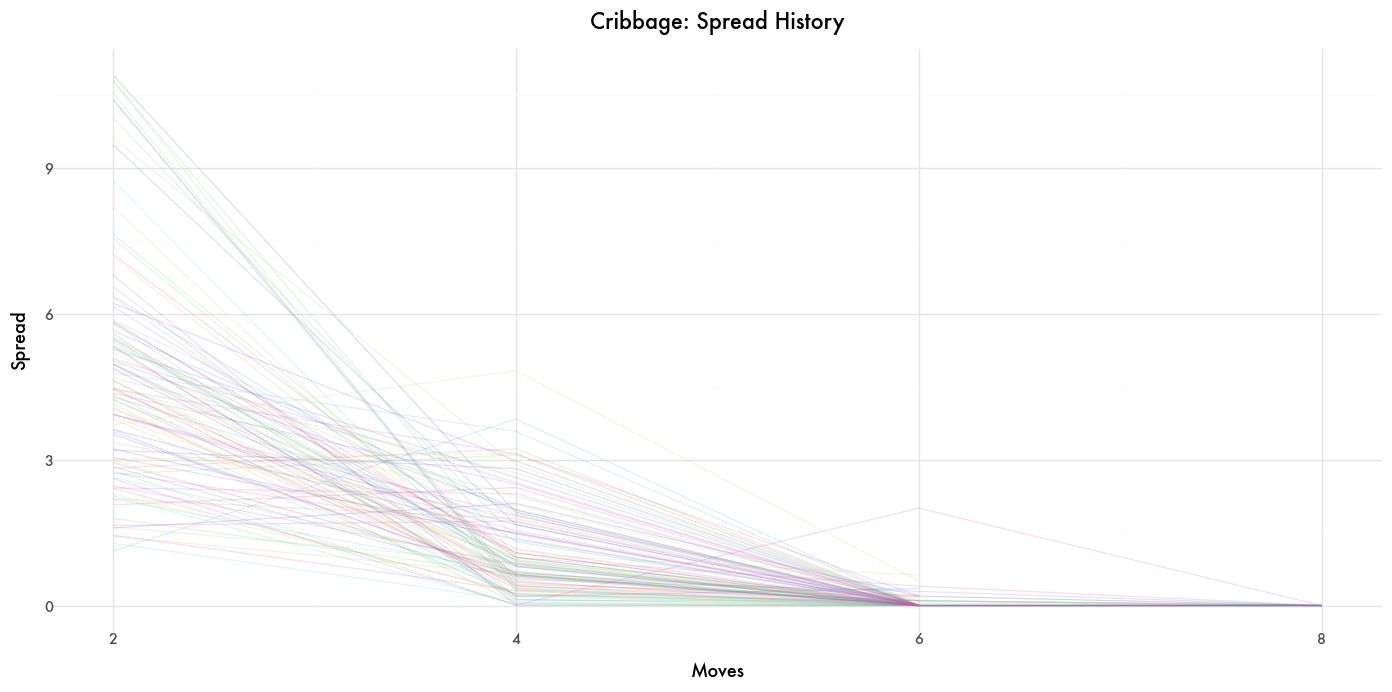

In [181]:
splot = (ggplot(spreadframe[(spreadframe["game"] == game) & (spreadframe["pmove"]%2 == 0)], 
       aes(x="pmove", y="spread", color="run"))
 + geom_line(alpha=0.2)
# + geom_smooth(method="loess", size=2, span=0.1)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(14, 7))
 + labs(x='Moves', y='Spread', title=game + ": Spread History")
)
splot.save("Spread.png")
splot.show()

In [144]:
spreadframe[(spreadframe["game"] == game)]

,game,numPlayers,ai,imperfect,samples,tests,run,pmove,player,spread
0,Cribbage,2,MR,PRIVATE,10,1000,1,1,0,1.989630
1,Cribbage,2,MR,PRIVATE,10,1000,1,2,0,4.241591
2,Cribbage,2,MR,PRIVATE,10,1000,1,3,0,0.597542
3,Cribbage,2,MR,PRIVATE,10,1000,1,4,0,0.434064
4,Cribbage,2,MR,PRIVATE,10,1000,1,5,0,0.000000
...,...,...,...,...,...,...,...,...,...,...
695,Cribbage,2,MR,PRIVATE,10,1000,100,3,0,1.653692
696,Cribbage,2,MR,PRIVATE,10,1000,100,4,0,0.249646
697,Cribbage,2,MR,PRIVATE,10,1000,100,5,0,0.001442
698,Cribbage,2,MR,PRIVATE,10,1000,100,6,0,0.000000


/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 8 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: Spread.png


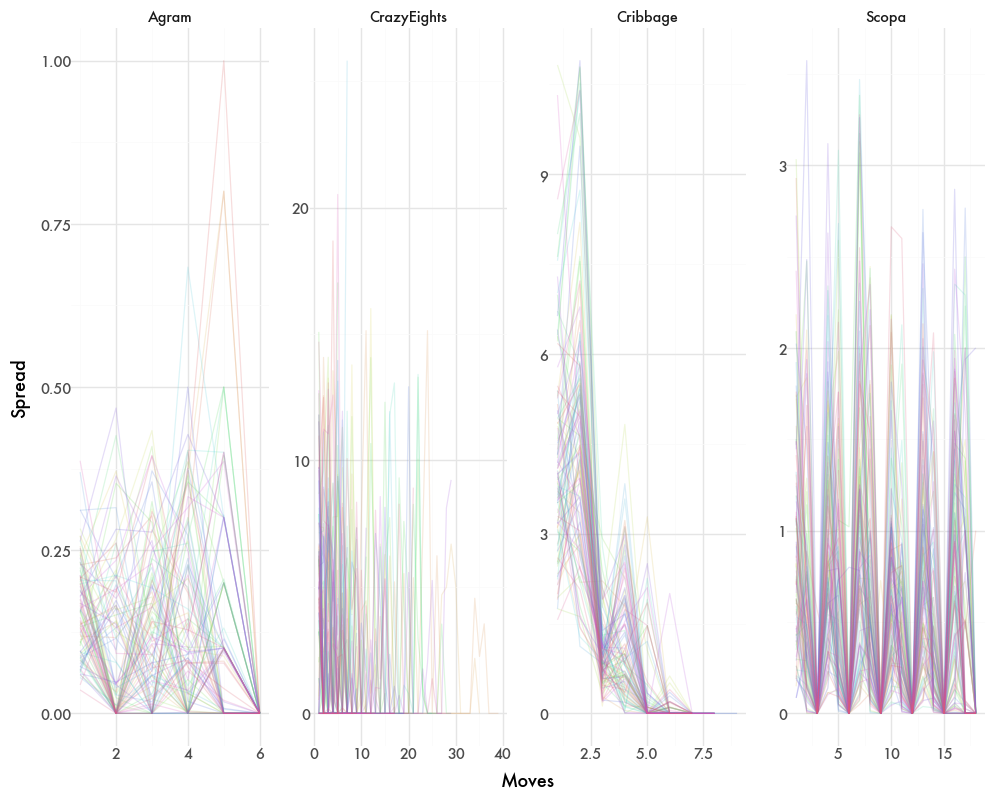

In [145]:
splot = (ggplot(spreadframe, 
       aes(x="pmove", y="spread", color="run"))
 + geom_line(alpha=0.2)
 + facet_wrap("game", scales = "free", ncol=5)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(10, 8))
 + labs(x='Moves', y='Spread')
)
splot.save("Spread.png")
splot.show()

In [ ]:
splot = (ggplot(spreadframe, 
       aes(x="pmove", y="spread", color="run"))
 + geom_line(alpha=0.2)
 + facet_wrap("game", scales = "free", ncol=5)
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(legend_position='none', figure_size=(10, 8))
 + labs(x='Moves', y='Spread')
)
splot.save("Spread.png")
splot.show()

# Lead History 

First, we create the Dataframe for storing all of the game statistics for the lead histories, then we can use this to project multiple graphs.

The **Security** and **Drama** Heuristics are calculated as part of this process.

In [165]:
first = True
for index, row in gameframe.iterrows():
    if row["game"] != "Blackjack" and row["game"] != "GoFish" and row["game"] != "Rummy" and row["game"] != "Skittgube":
        #gf = pd.read_csv(row["fileprefix"] + row["game"] + "/" + str(row["player"]) + "/" + "P" + "R" * (row["player"] - 1) + "/lead.csv")
        gf = pd.read_csv(fileprefix + row["game"] + "/" + str(row["player"]) + "/" + "M" * (row["player"]) + "/lead.csv")
        gf["game"] = row["game"]
        if first:
            leadframe = gf
            first = False
        else:
            leadframe = pd.concat([leadframe, gf])
leadframe

,game,numPlayers,ai,imperfect,samples,tests,run,move,recorder,player,score,rank,rankestimate
0,Agram,3,MMM,PRIVATE,10,1000,1,1,1,1,0.083448,3,0.541724
1,Agram,3,MMM,PRIVATE,10,1000,1,1,1,2,0.424672,2,0.712336
2,Agram,3,MMM,PRIVATE,10,1000,1,1,1,3,0.491880,1,0.745940
3,Agram,3,MMM,PRIVATE,10,1000,1,2,2,1,0.224114,3,0.612057
4,Agram,3,MMM,PRIVATE,10,1000,1,2,2,2,0.520966,2,0.760483
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7395,Scopa,2,MM,PRIVATE,10,1000,100,35,1,2,2.000000,1,1.000000
7396,Scopa,2,MM,PRIVATE,10,1000,100,36,2,1,1.000000,2,0.000000
7397,Scopa,2,MM,PRIVATE,10,1000,100,36,2,2,2.000000,1,1.000000
7398,Scopa,2,MM,PRIVATE,10,1000,100,37,1,1,1.000000,2,0.000000


In [166]:
leadframe[(leadframe["game"]=="Klaverjassen") & (leadframe["run"] == 1)]

,game,numPlayers,ai,imperfect,samples,tests,run,move,recorder,player,score,rank,rankestimate
0,Klaverjassen,4,MMMM,PRIVATE,10,1000,1,1,1,1,181.256715,2,0.997451
1,Klaverjassen,4,MMMM,PRIVATE,10,1000,1,1,1,2,33.334546,4,0.336736
2,Klaverjassen,4,MMMM,PRIVATE,10,1000,1,1,1,3,181.256715,1,0.997451
3,Klaverjassen,4,MMMM,PRIVATE,10,1000,1,1,1,4,33.334546,3,0.336736
4,Klaverjassen,4,MMMM,PRIVATE,10,1000,1,2,1,1,180.533165,2,0.991969
...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,Klaverjassen,4,MMMM,PRIVATE,10,1000,1,33,4,4,11.000000,3,0.333333
132,Klaverjassen,4,MMMM,PRIVATE,10,1000,1,34,1,1,171.000000,2,1.000000
133,Klaverjassen,4,MMMM,PRIVATE,10,1000,1,34,2,2,11.000000,4,0.333333
134,Klaverjassen,4,MMMM,PRIVATE,10,1000,1,34,3,3,171.000000,1,1.000000


In [167]:
leadframe[leadframe['rank'].isnull()]

,game,numPlayers,ai,imperfect,samples,tests,run,move,recorder,player,score,rank,rankestimate


In [168]:
first = True
for game in gameframe["game"]:
    if game != "Blackjack" and game != "GoFish" and game != "Rummy" and game != "Skittgube":
        print(game)
        pv = gameframe[gameframe["game"] == game]["player"].values[0]
        myl = leadframe[leadframe["game"] == game]
        for run in range(1, 101):
            for player in range(1, pv + 1):
                myl2 = myl[(myl["run"] == run)  & (myl["player"] == player)]
                x = myl2["rankestimate"]
                length = myl2["move"].max()
                px = [x / (length - 1) for x in range(length)]
                f = interp1d(px, x)
                xnew = np.linspace(0, 1, num=101)
                ynew = f(xnew)
                n = pd.DataFrame([xnew, ynew], index=["portion", "estimate"]).T
                n["game"] = game
                n["run"] = run
                n["player"] = player
                n["rank"] = myl2["rank"].values[0]
                if first:
                    leads = n
                    first = False
                else:
                    leads = pd.concat([leads, n])

Agram
CrazyEights
Cribbage
Klaverjassen
Scopa


In [169]:
leads

,portion,estimate,game,run,player,rank
0,0.00,0.541724,Agram,1,1,3
1,0.01,0.554384,Agram,1,1,3
2,0.02,0.567044,Agram,1,1,3
3,0.03,0.579704,Agram,1,1,3
4,0.04,0.592364,Agram,1,1,3
...,...,...,...,...,...,...
96,0.96,1.000000,Scopa,100,2,1
97,0.97,1.000000,Scopa,100,2,1
98,0.98,1.000000,Scopa,100,2,1
99,0.99,1.000000,Scopa,100,2,1


In [170]:
leads["player"] = leads["player"].astype(str)
leads["run"] = leads["run"].astype(str)
leads["rank"] = leads["rank"].astype(str)
leads[(leads["game"] == "Cuckoo") & (leads["run"] == "1")]

,portion,estimate,game,run,player,rank


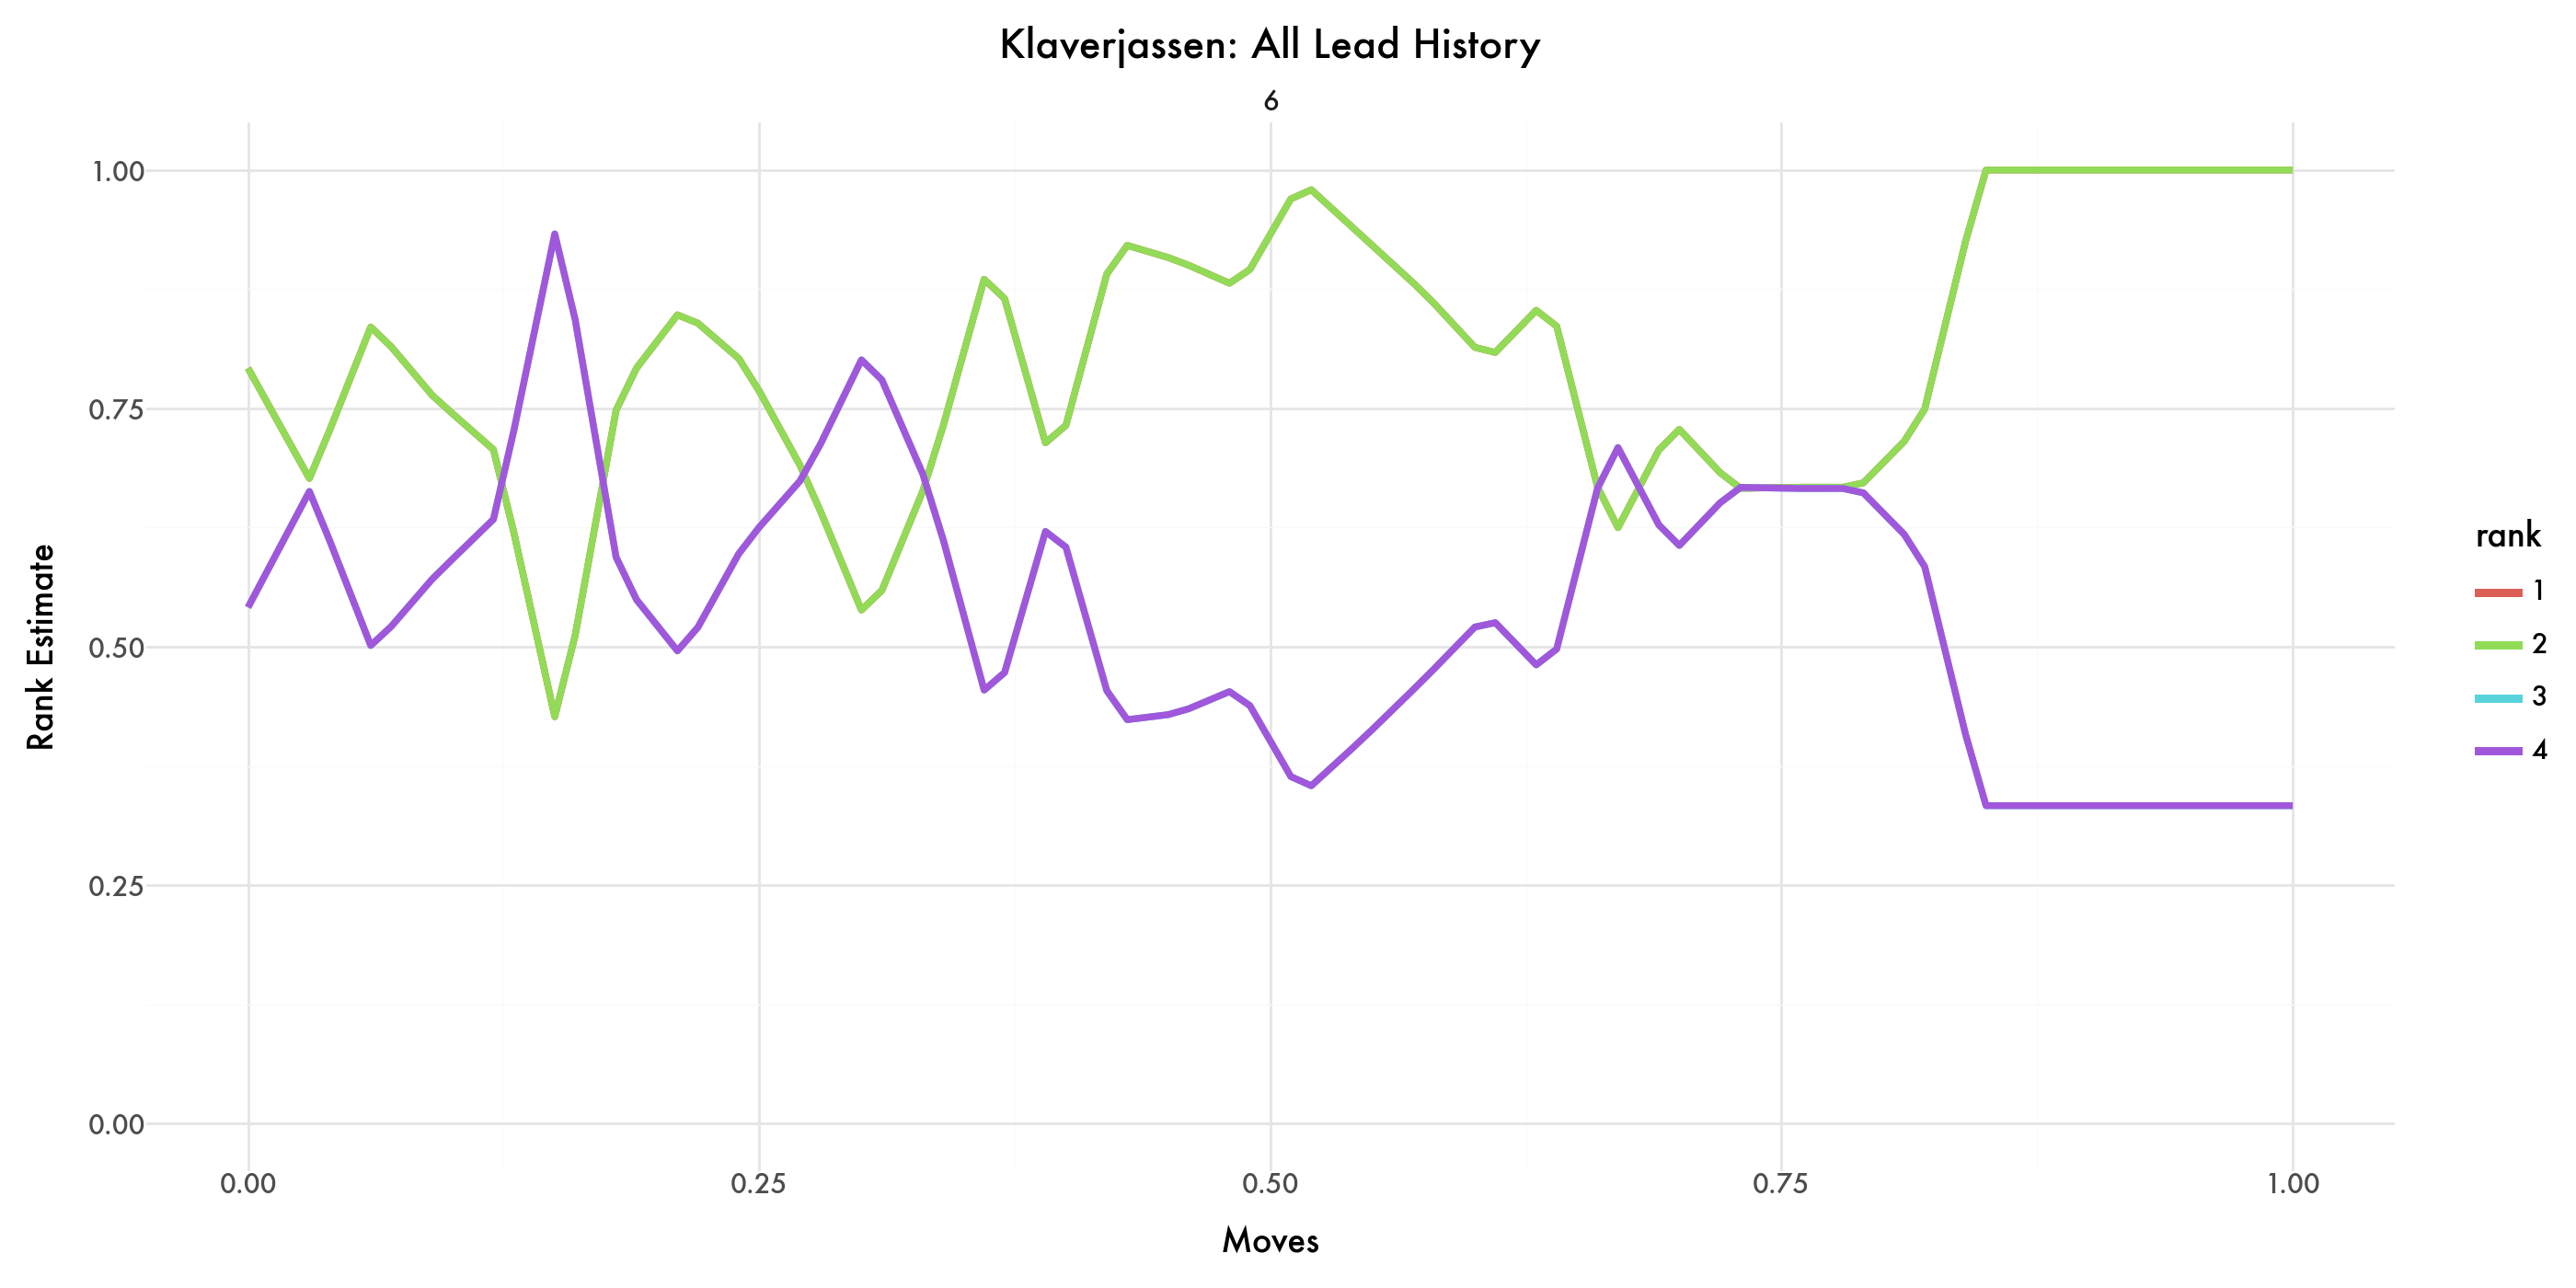

In [172]:
game = "Klaverjassen"
iter="6"
(ggplot(leads[(leads["game"] == game) & (leads["run"]== iter)], 
       aes(x="portion", y="estimate", color="rank"))
 + geom_line(size=1.5)
 + ylim(0, 1)
 + facet_wrap("run", scales = "free_x")
 + theme_minimal(base_family="Futura", base_size=13)
 + theme(figure_size=(14, 7))
 + labs(x='Moves', y='Rank Estimate', title=game + ": All Lead History")
)

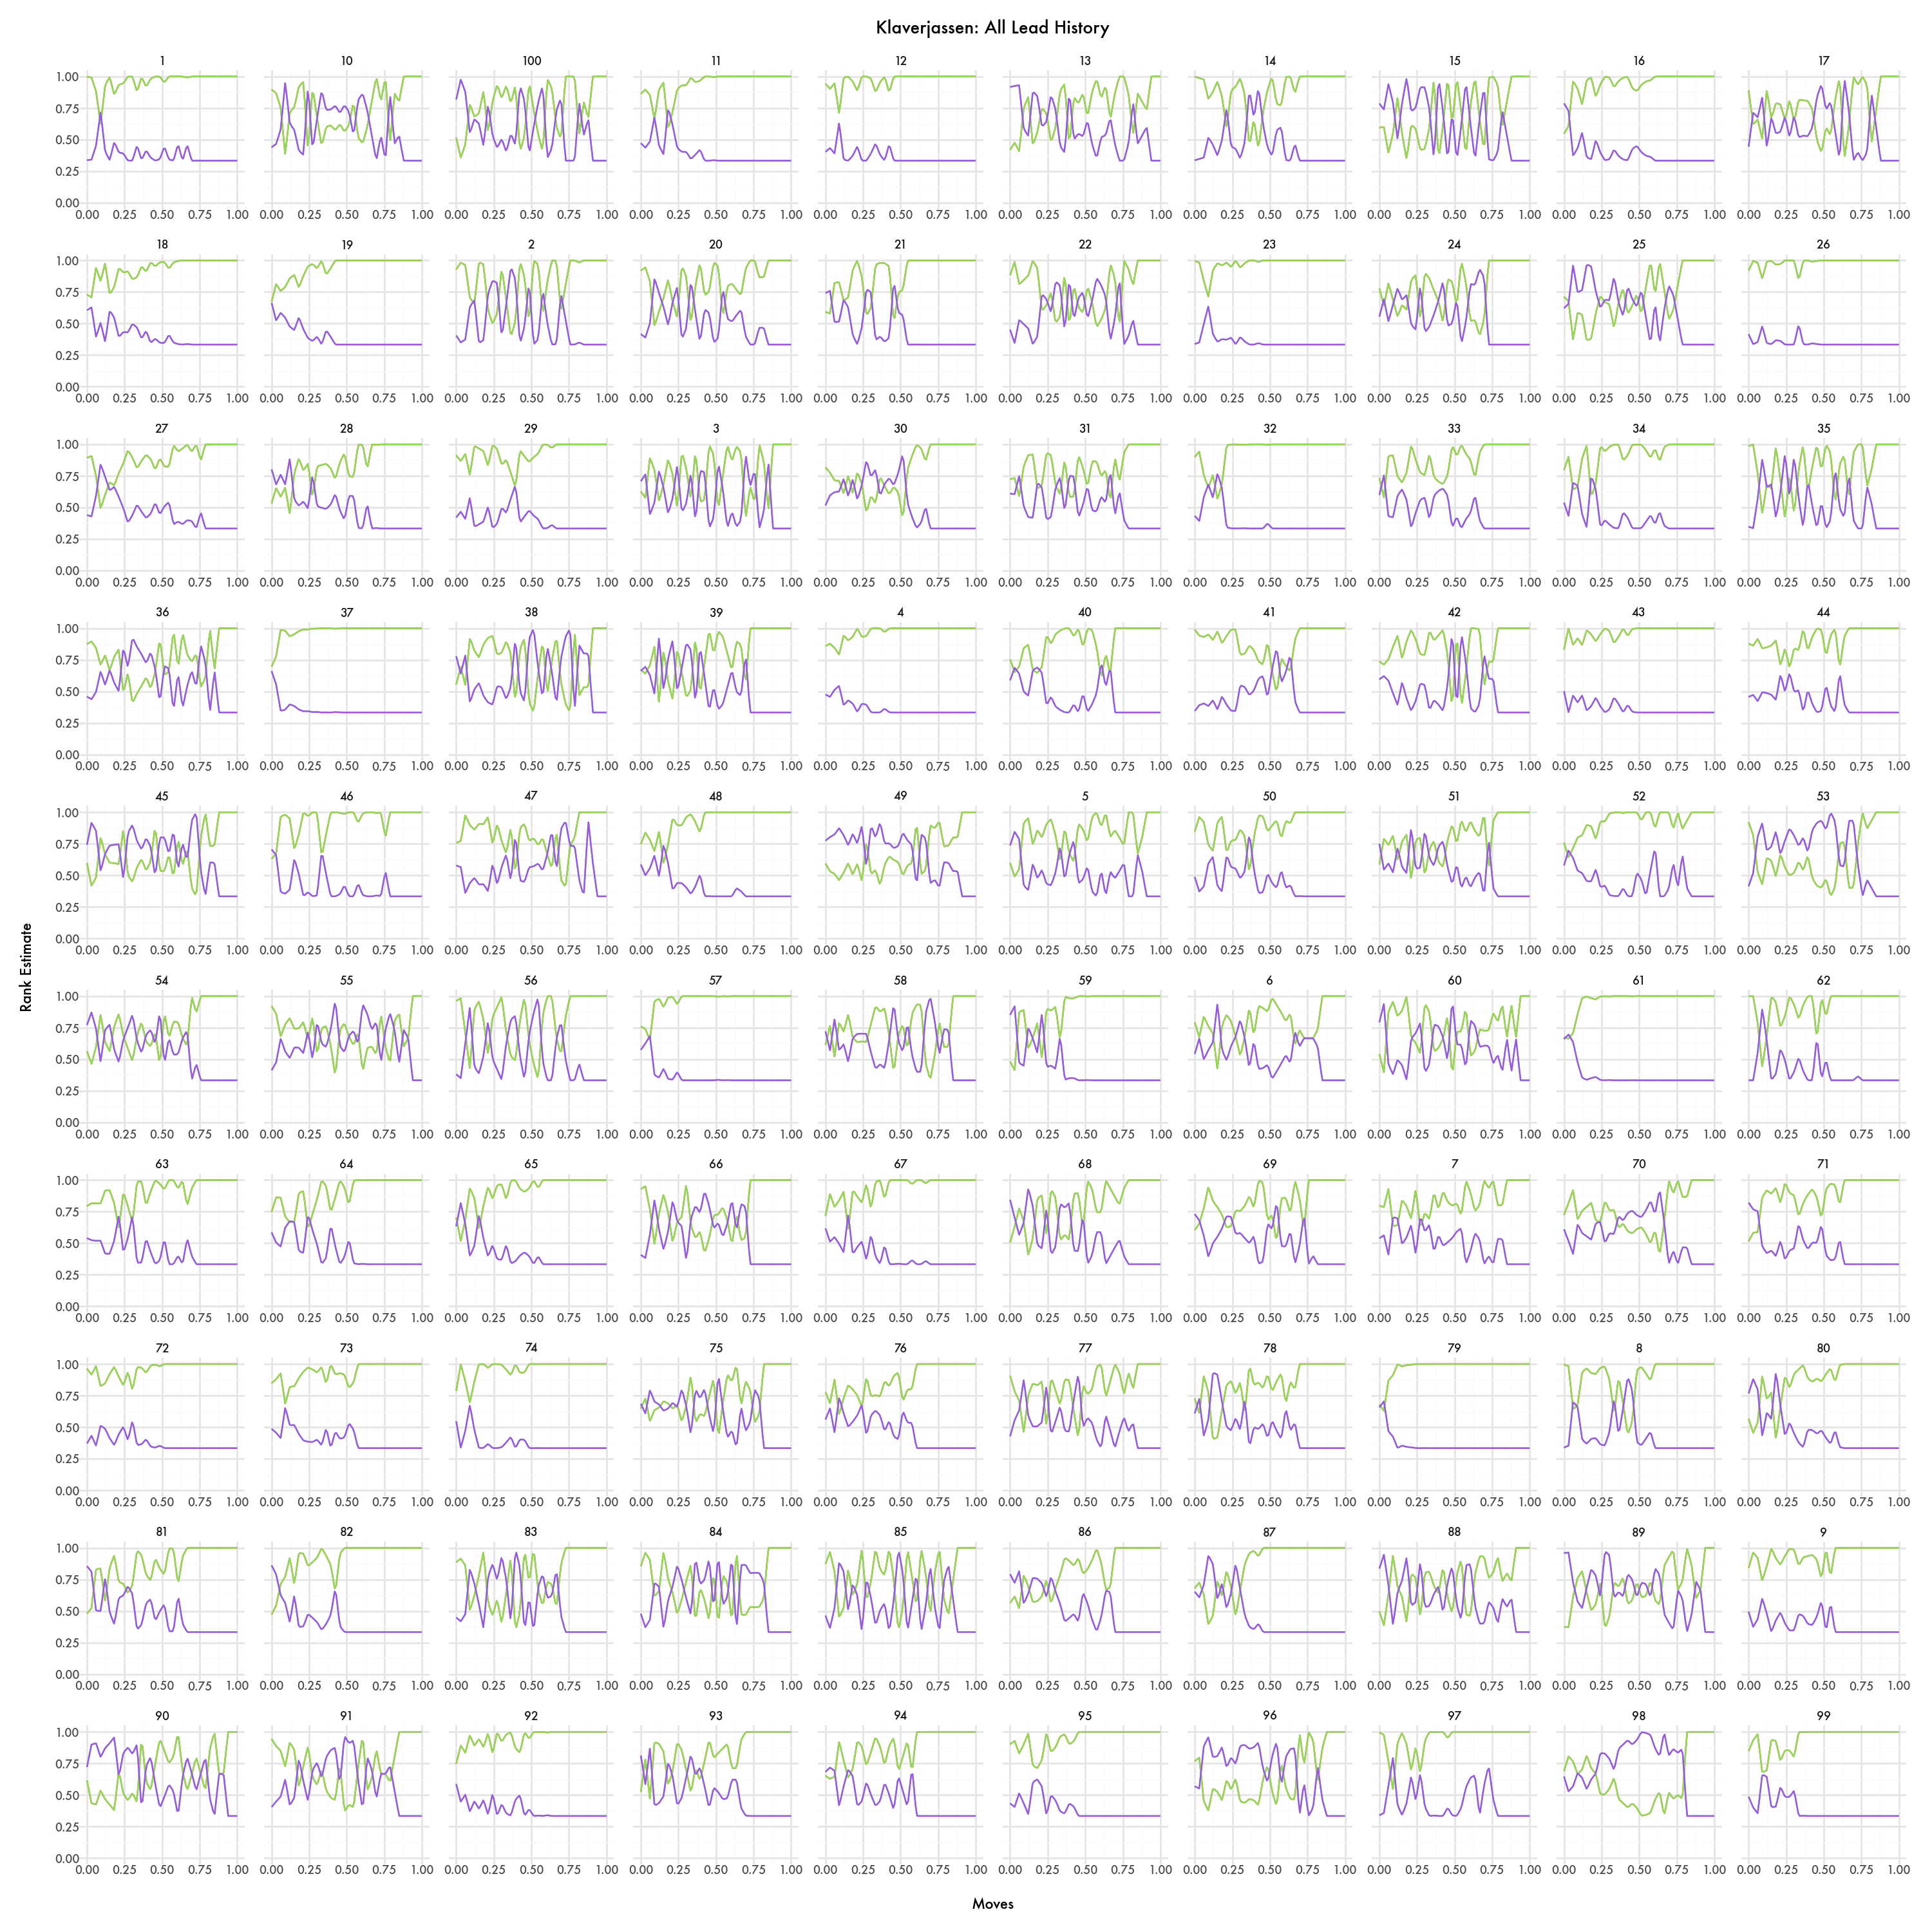

In [173]:
(ggplot(leads[(leads["game"] == game)], 
       aes(x="portion", y="estimate", color="rank"))
 + geom_line()
 + ylim(0, 1)
 + facet_wrap("run", scales = "free_x")
 + theme_minimal(base_family="Futura", base_size=8)
 + theme(legend_position='none', figure_size=(15, 15))
 + labs(x='Moves', y='Rank Estimate', title=game + ": All Lead History")
)

/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_smooth : Removed 6 rows containing missing values.


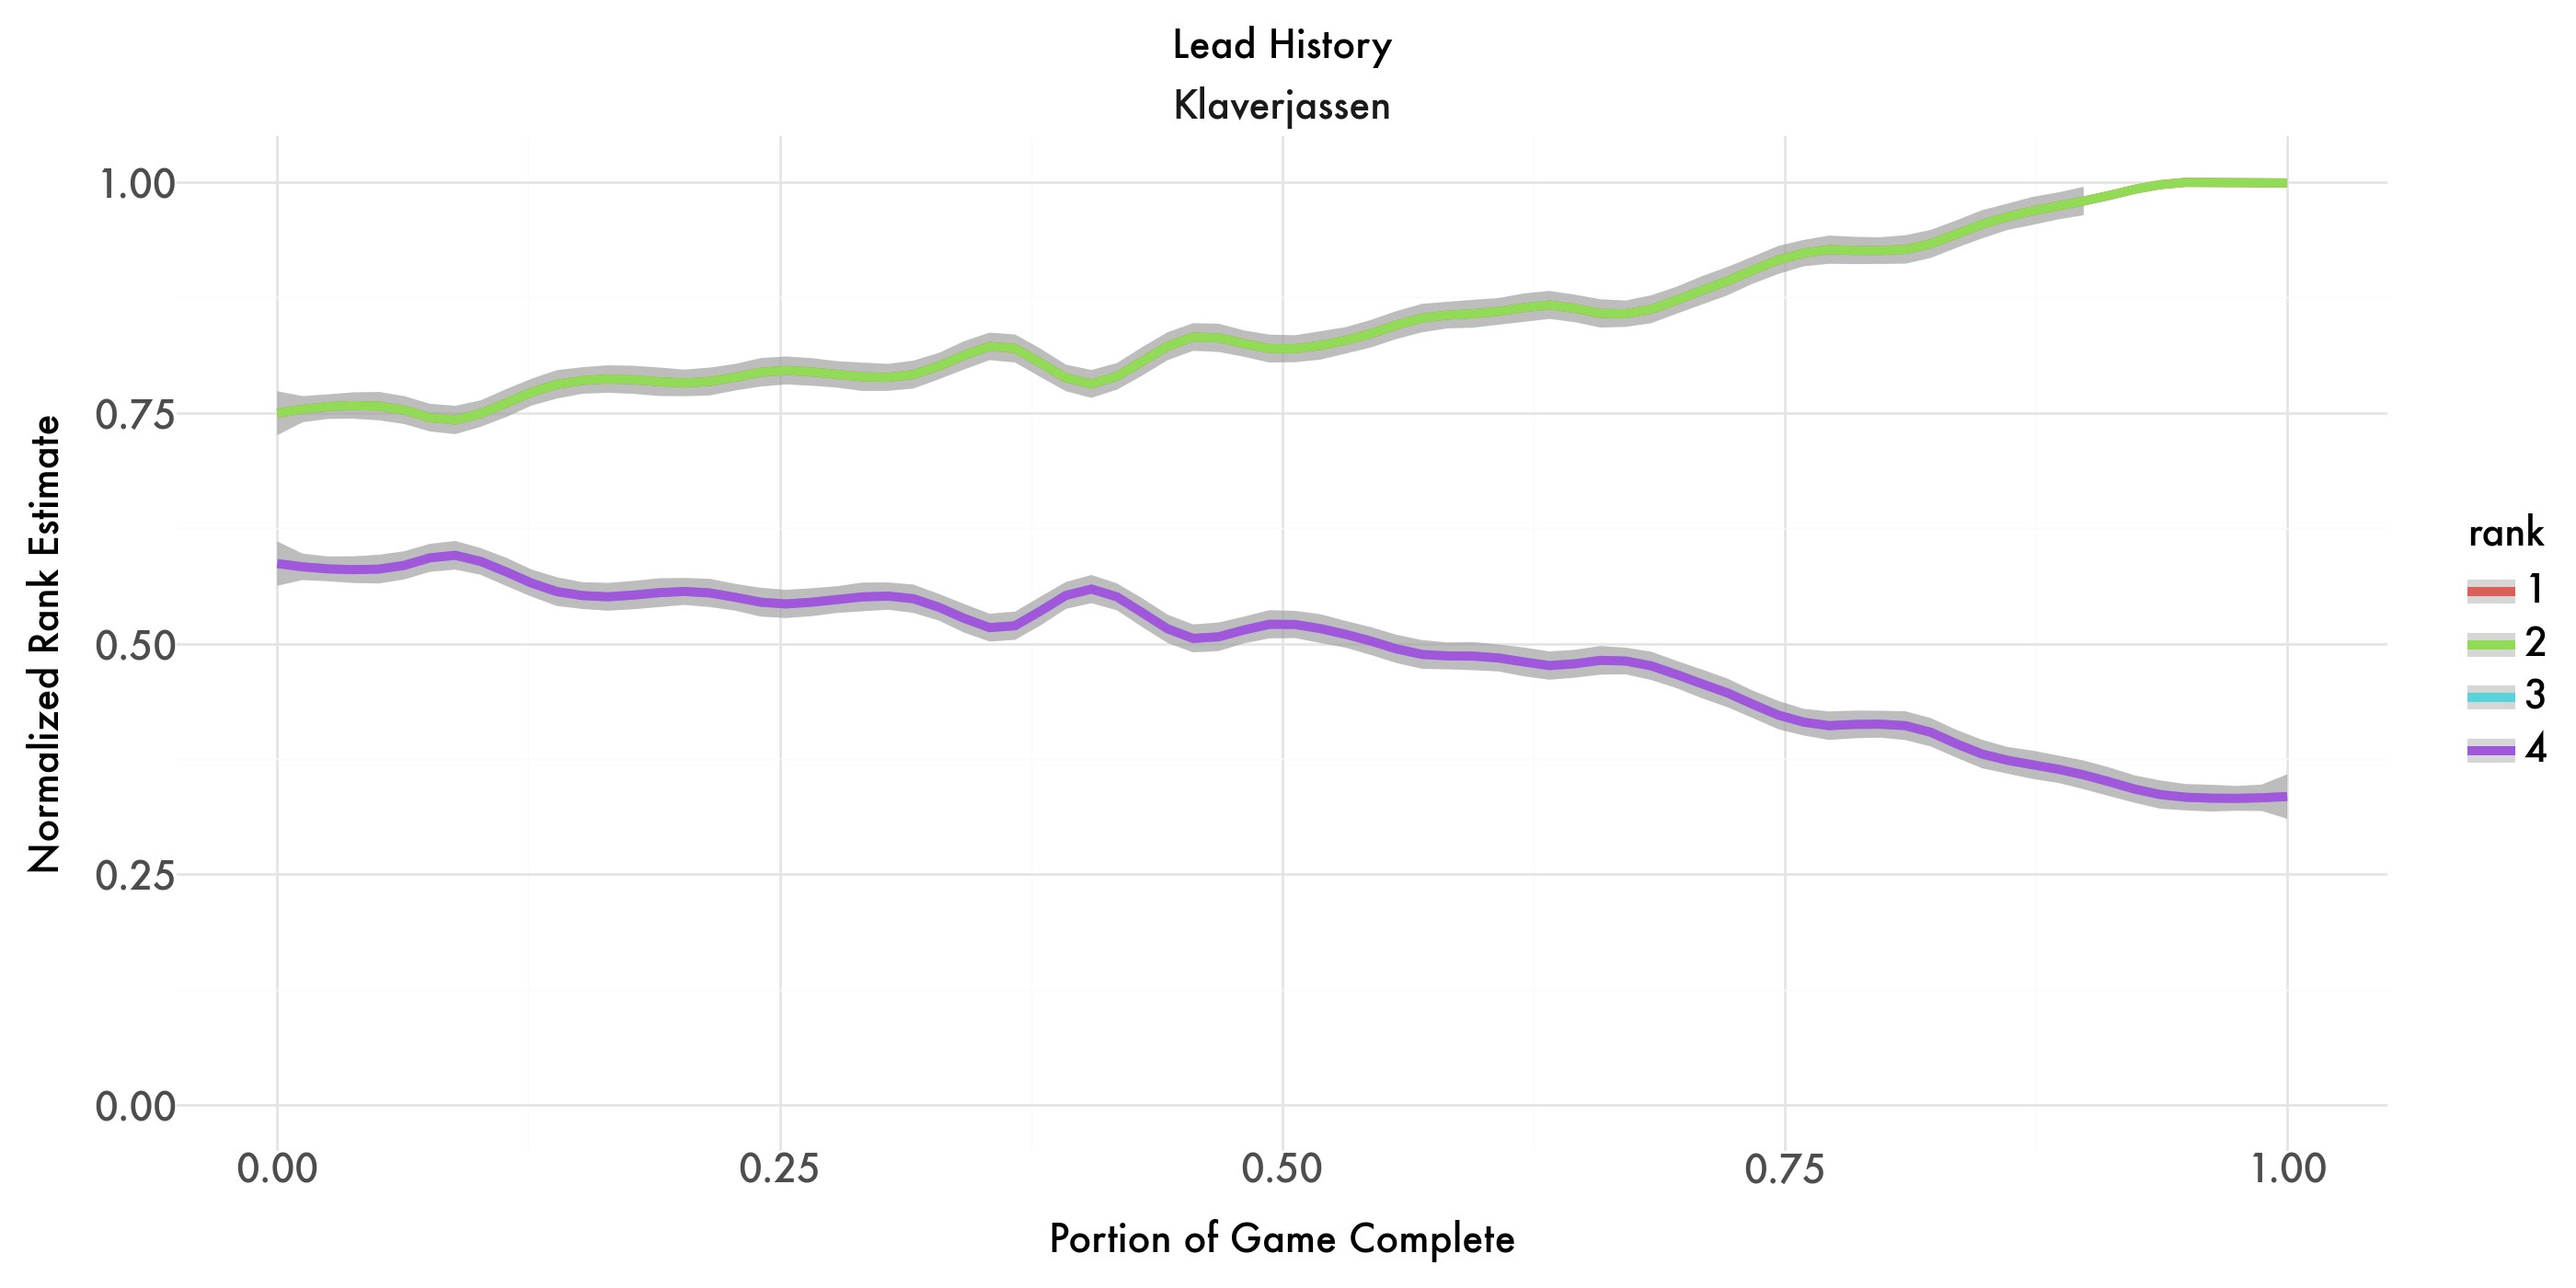

In [174]:

(ggplot(leads[(leads["game"] == game)], 
       aes(x="portion", y="estimate", color="rank"))
    + geom_smooth(method="loess", size=2, span=0.1)
    + ylim(0, 1)
    + facet_wrap("game")
    + theme_minimal(base_family="Futura", base_size=13)
    + theme(figure_size=(14, 7), text=element_text(size=15))
    + labs(x='Portion of Game Complete', y='Normalized Rank Estimate', title="Lead History")
)


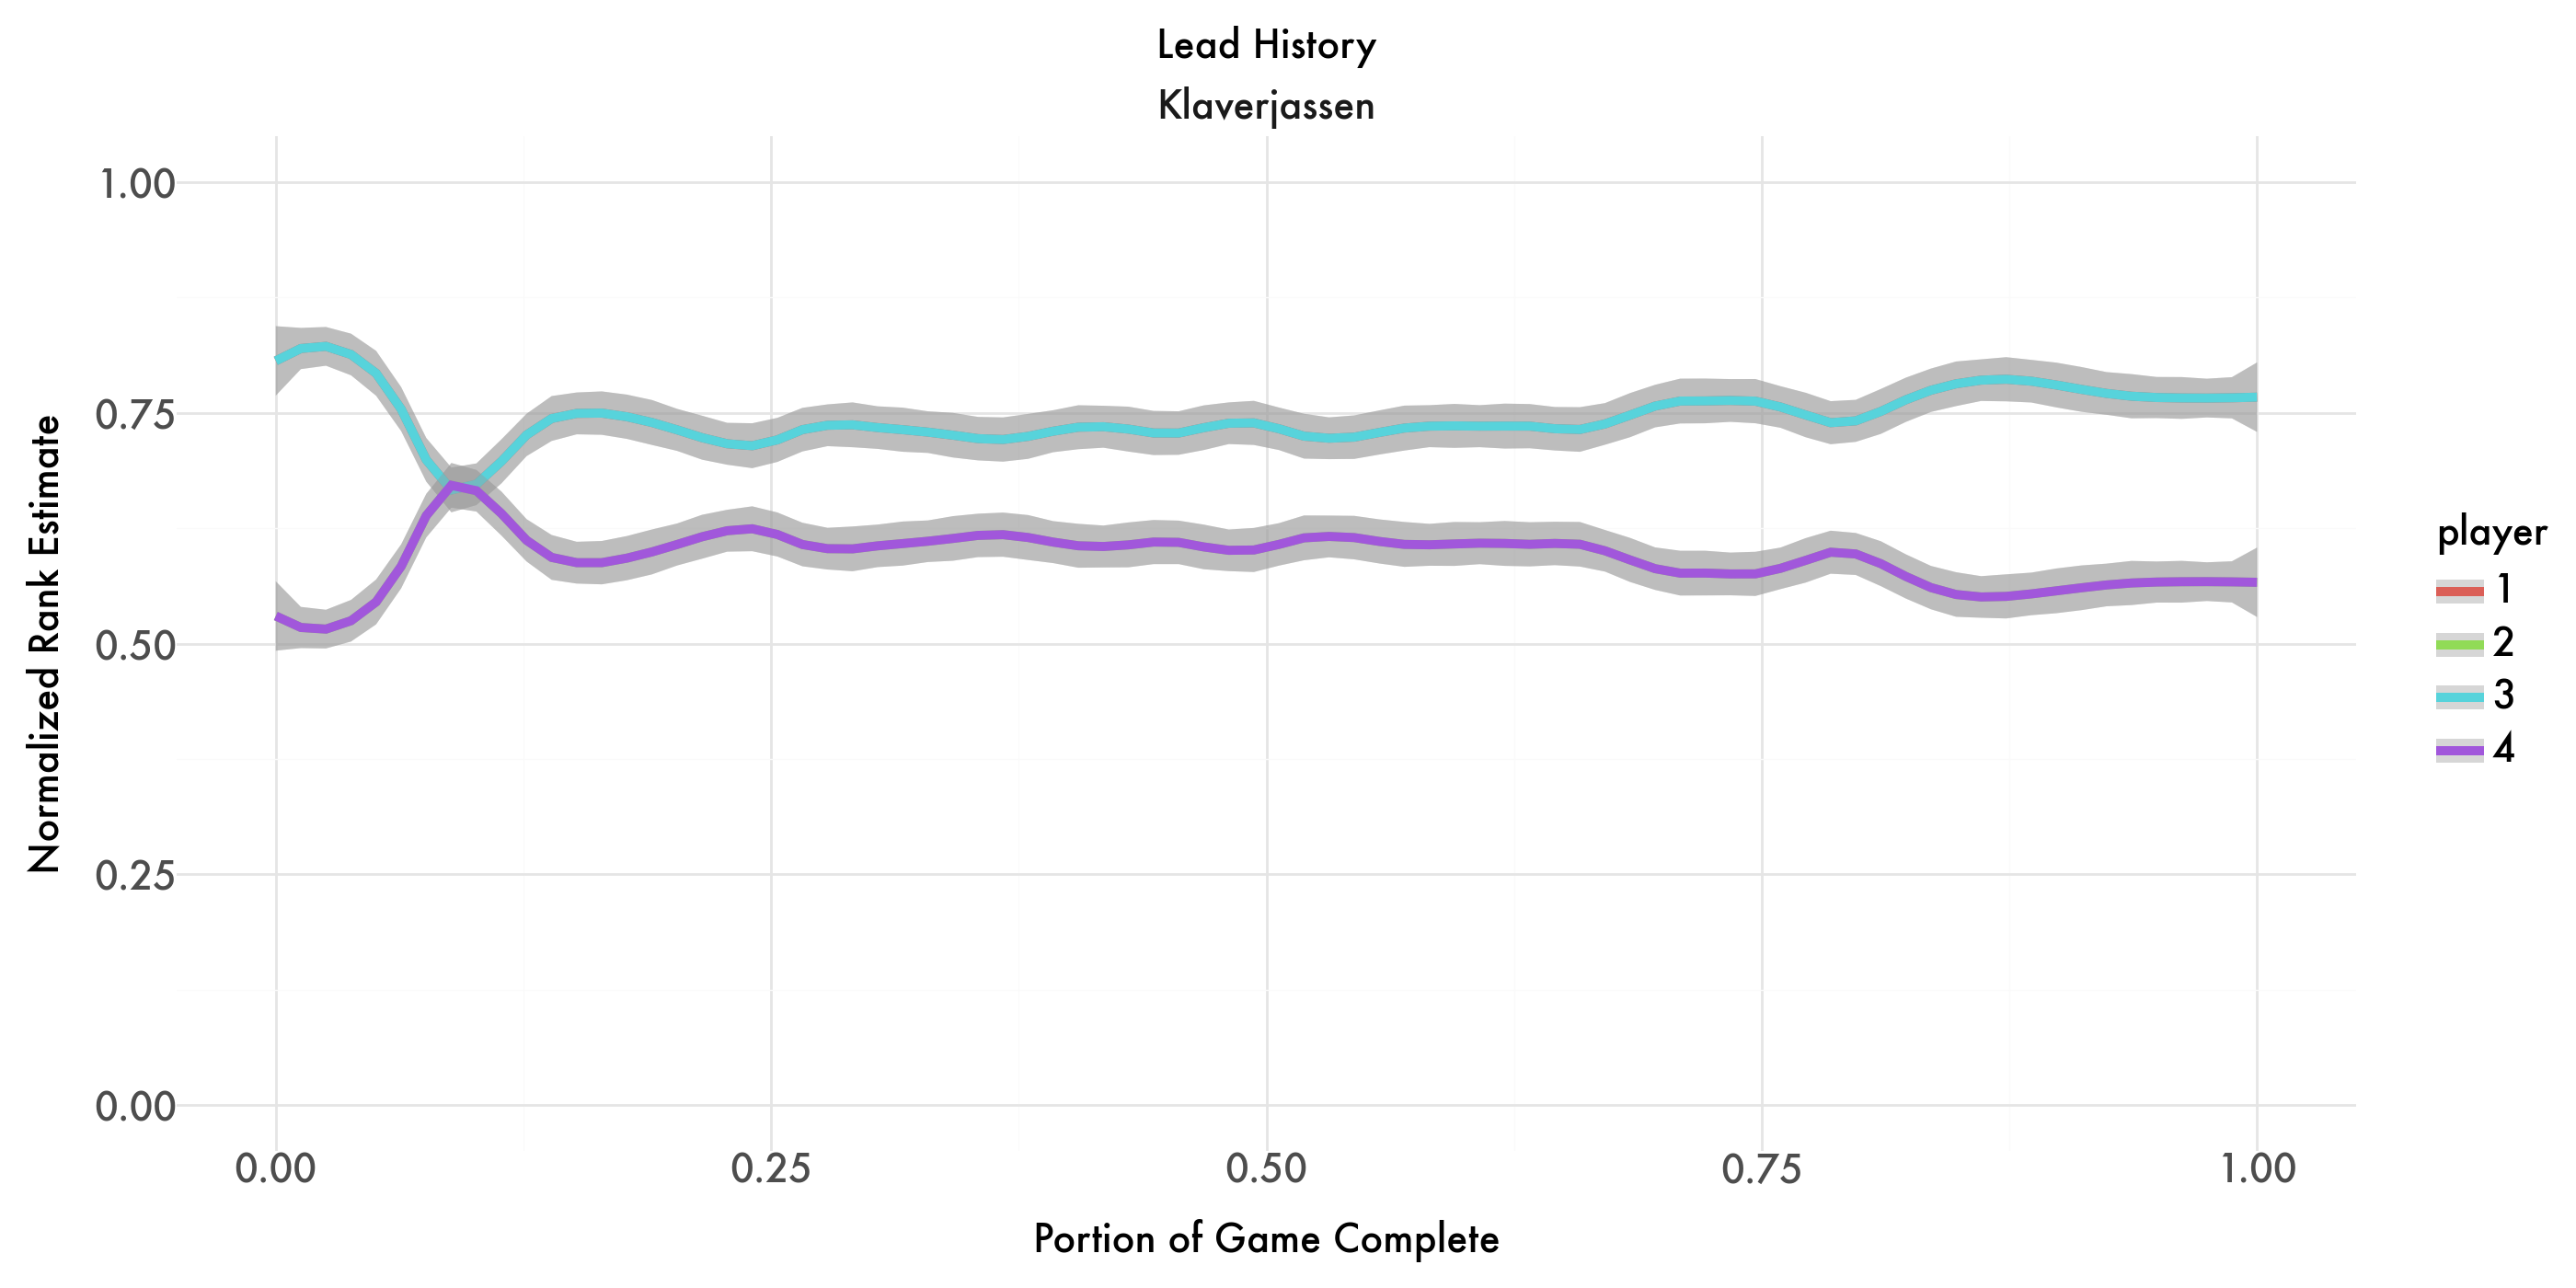

In [175]:
(ggplot(leads[(leads["game"] == game)], 
       aes(x="portion", y="estimate", color="player"))
    + geom_smooth(method="loess", size=2, span=0.1)
    + ylim(0, 1)
    + facet_wrap("game")
    + theme_minimal(base_family="Futura", base_size=13)
    + theme(figure_size=(14, 7), text=element_text(size=15))
    + labs(x='Portion of Game Complete', y='Normalized Rank Estimate', title="Lead History")
)


/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 5 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: LeadHistory.png
/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_smooth : Removed 16 rows containing missing values.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_smooth : Removed 16 rows containing missing values.


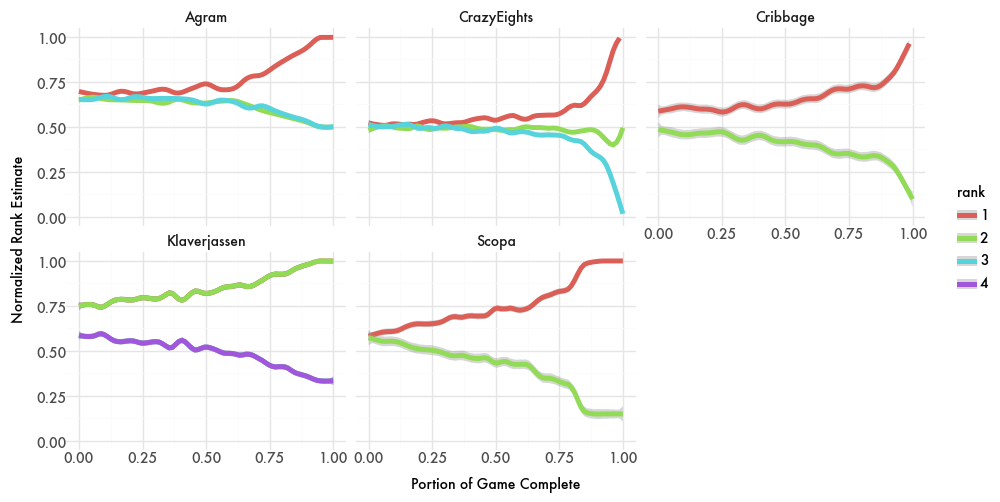

In [176]:
lh = (ggplot(leads, aes(x="portion", y="estimate", color="rank"))
    + geom_smooth(method="loess", size=2, span=0.1)
    + ylim(0, 1)
    + facet_wrap("game")
    + theme_minimal(base_family="Futura", base_size=10)
    + theme(figure_size=(10, 5), text=element_text(size=10))
    + labs(x='Portion of Game Complete', y='Normalized Rank Estimate')
)
lh.save("LeadHistory.png")
lh.show()

/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 10 x 5 in image.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: LeadHistory.png


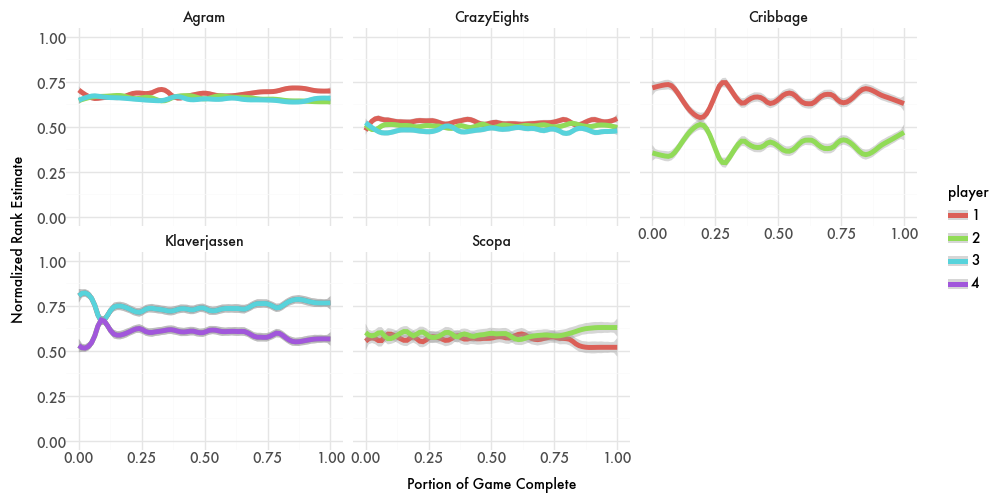

In [177]:
lh = (ggplot(leads, aes(x="portion", y="estimate", color="player"))
    + geom_smooth(method="loess", size=2, span=0.1)
    + ylim(0, 1)
    + facet_wrap("game")
    + theme_minimal(base_family="Futura", base_size=10)
    + theme(figure_size=(10, 5), text=element_text(size=10))
    + labs(x='Portion of Game Complete', y='Normalized Rank Estimate')
)
lh.save("LeadHistory.png")
lh.show()

In [60]:
(ggplot(leads, aes(x="portion", y="estimate", color="rank"))
    + geom_smooth(method="loess", size=2, span=0.1)
    + ylim(0, 1)
    + facet_wrap("game")
    + theme_minimal(base_family="Futura", base_size=10)
    + theme(figure_size=(14, 7), text=element_text(size=10))
    + labs(x='Portion of Game Complete', y='Score', title="Lead History")
)

KeyboardInterrupt: 

Use the following graph to look for turn order advantage.

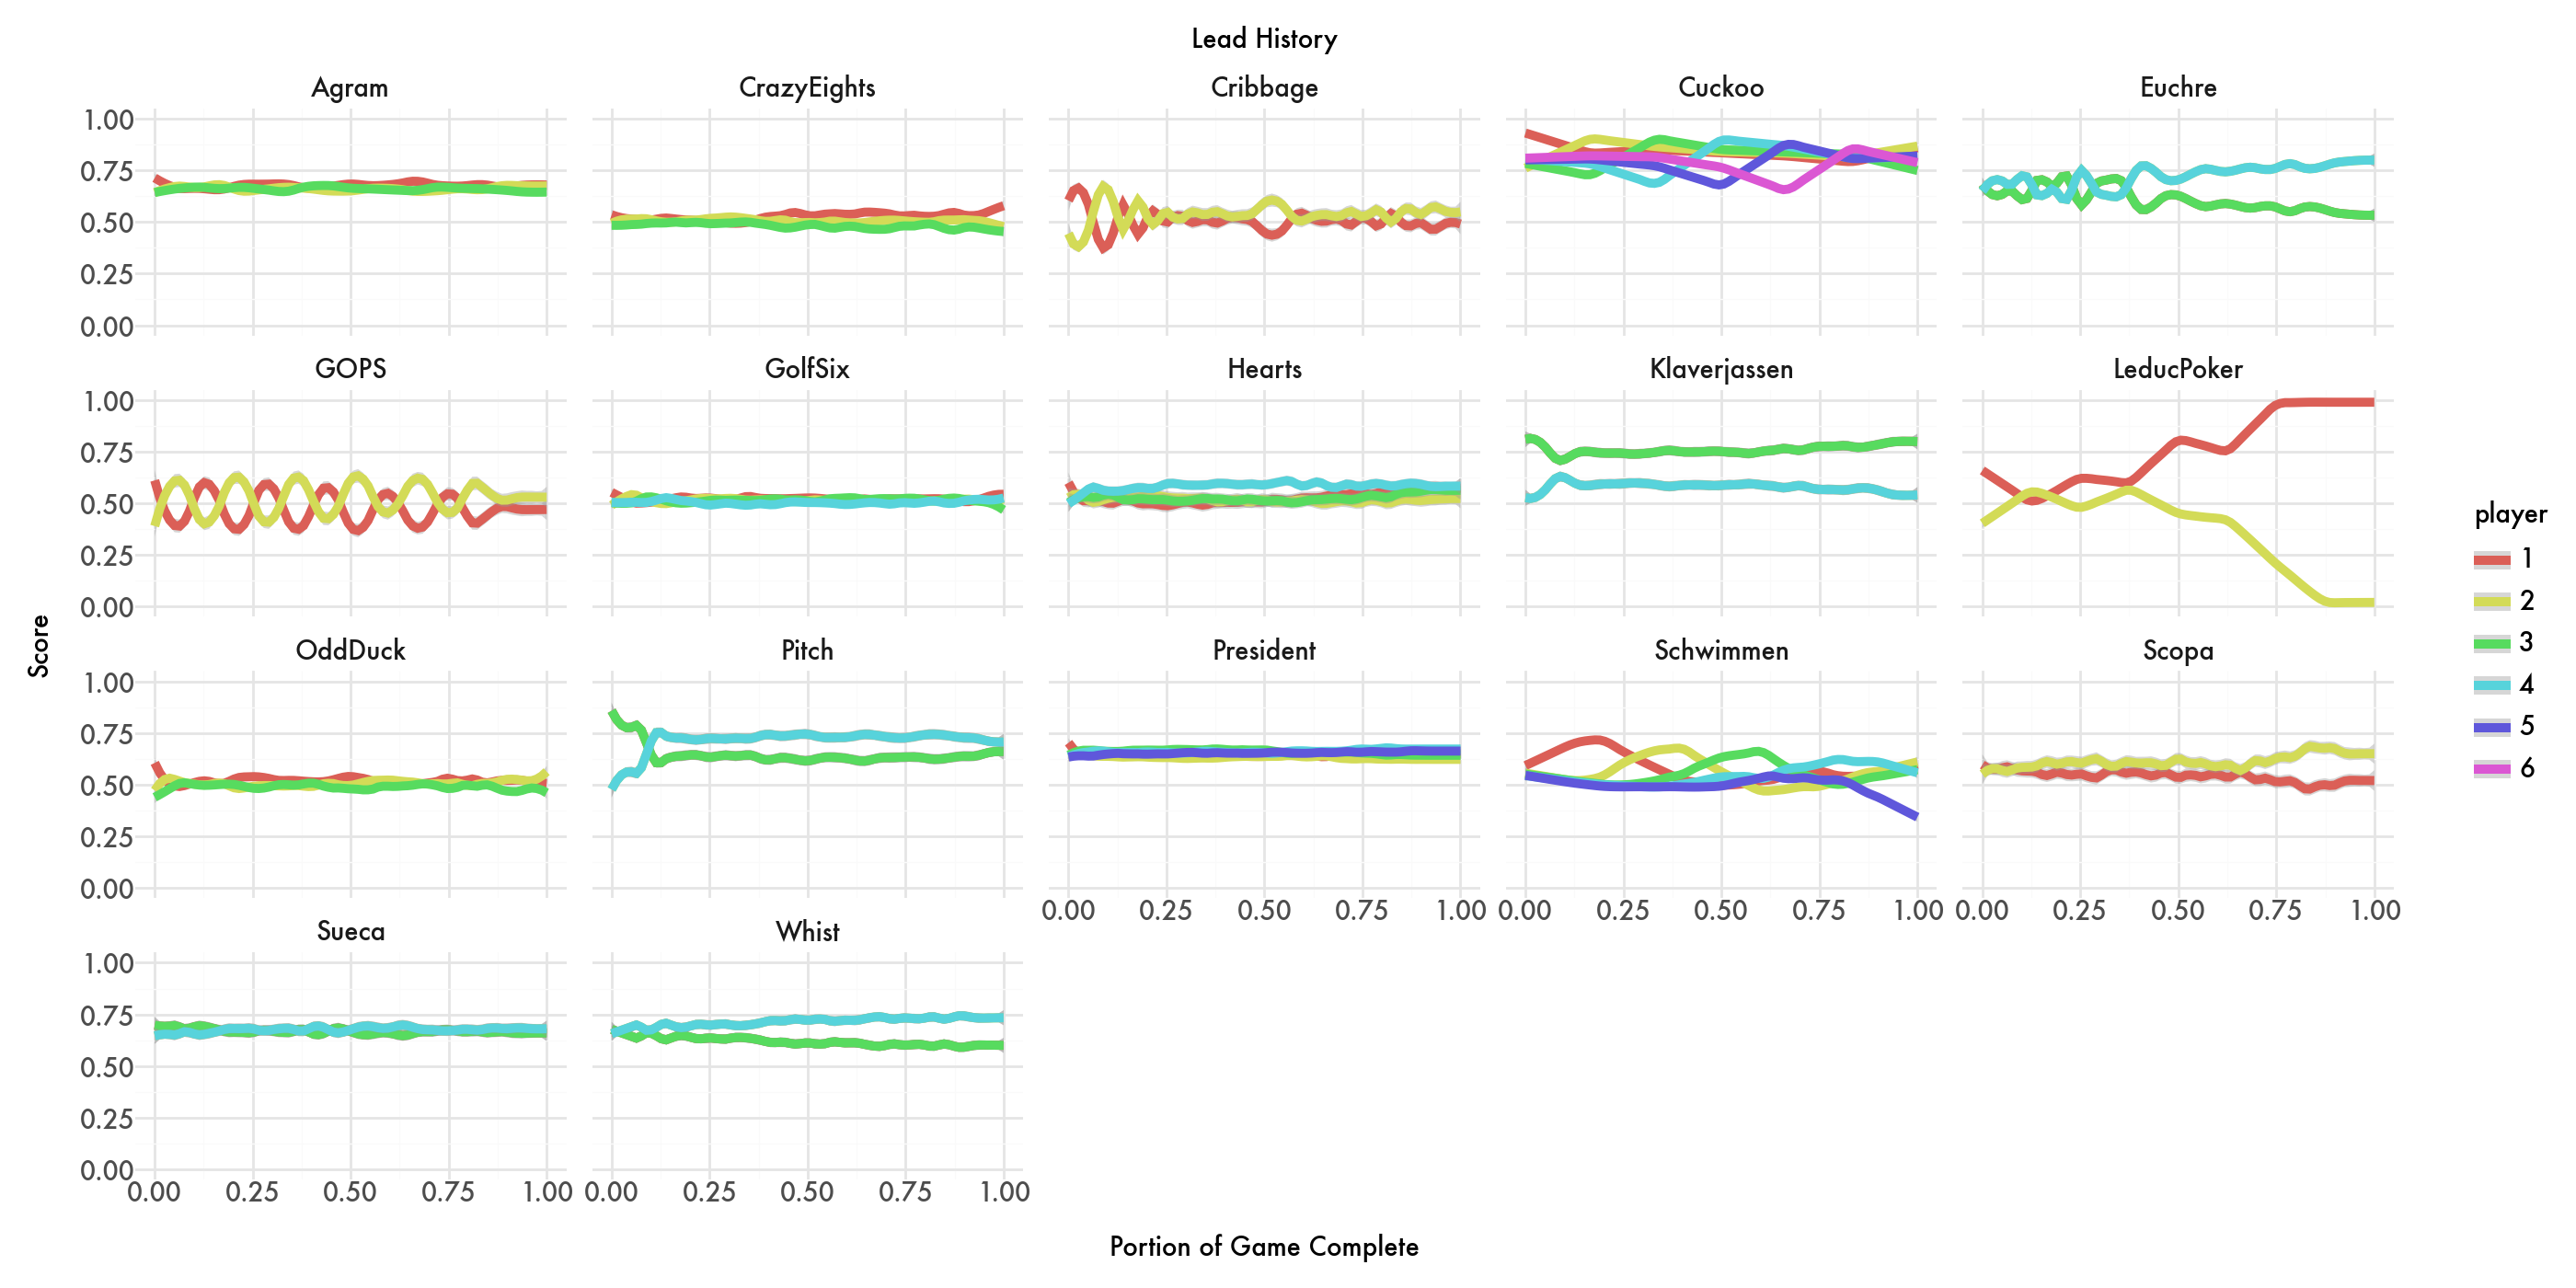

In [13]:
(ggplot(leads, aes(x="portion", y="estimate", color="player"))
    + geom_smooth(method="loess", size=2, span=0.1)
    + ylim(0, 1)
    + facet_wrap("game")
    + theme_minimal(base_family="Futura", base_size=10)
    + theme(figure_size=(14, 7), text=element_text(size=10))
    + labs(x='Portion of Game Complete', y='Normalized Rank Estimate', title="Lead History")
)

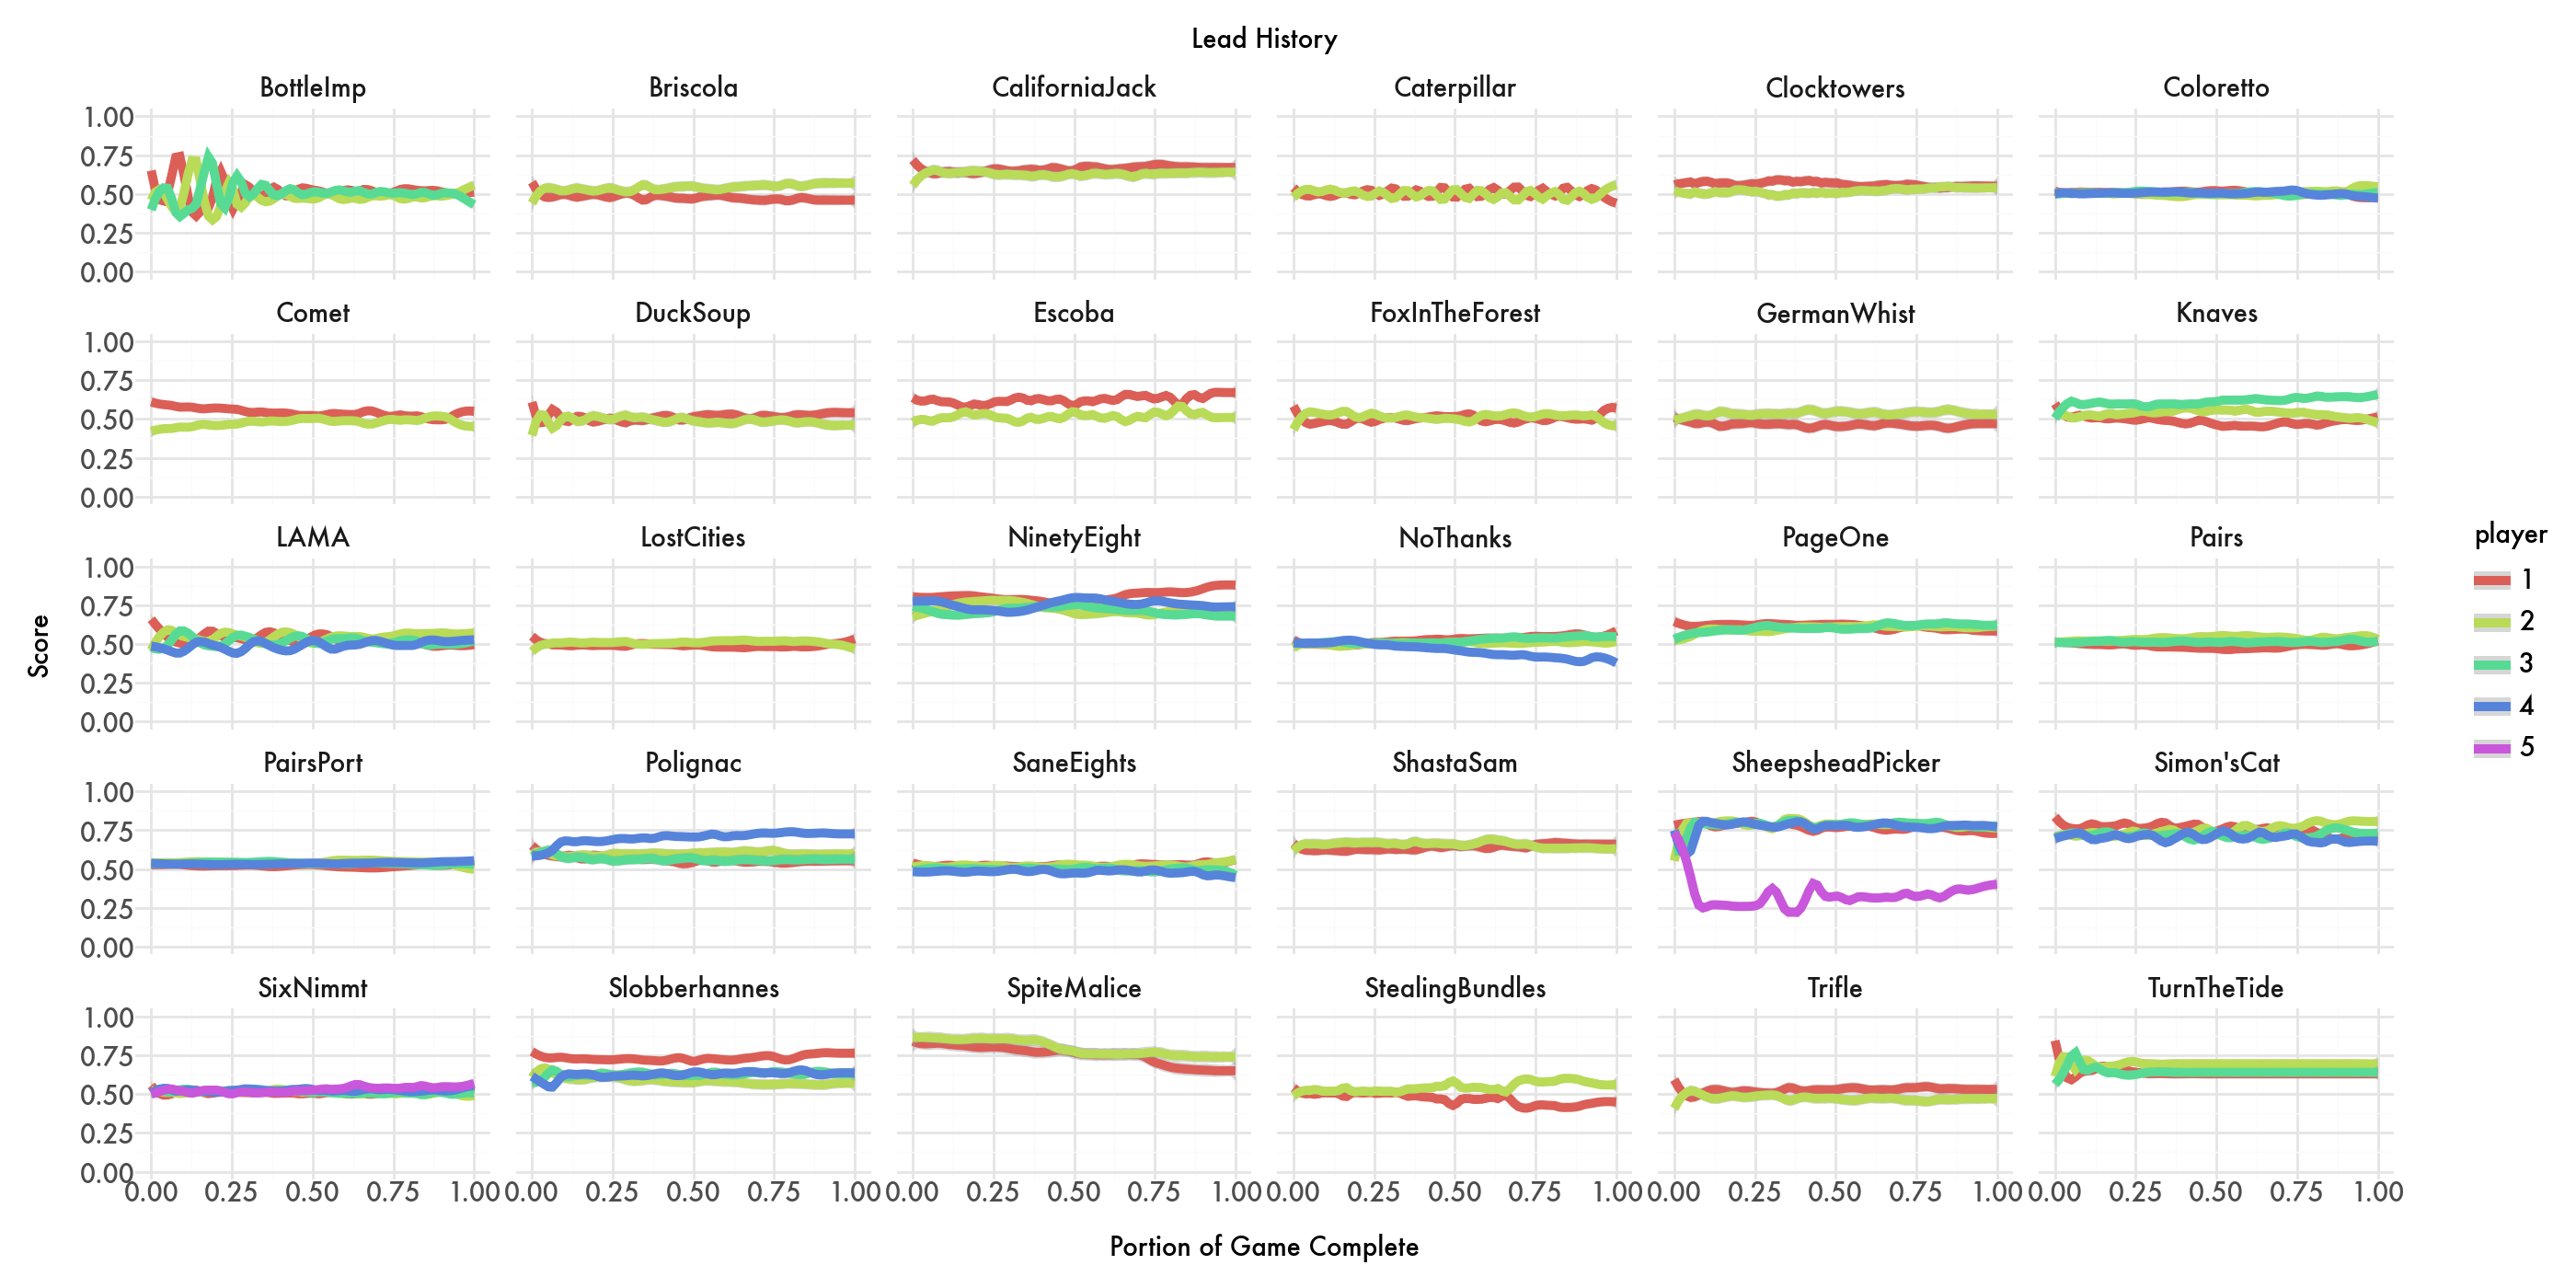

In [17]:
(ggplot(leads, aes(x="portion", y="estimate", color="player"))
    + geom_smooth(method="loess", size=2, span=0.1)
    + ylim(0, 1)
    + facet_wrap("game")
    + theme_minimal(base_family="Futura", base_size=10)
    + theme(figure_size=(14, 7), text=element_text(size=10))
    + labs(x='Portion of Game Complete', y='Score', title="Lead History")
)